# 안저 영상 혈관 굴곡도와 당뇨망막병증(DR) 등급: FIVES 학습부터 APTOS 분석까지

한 노트북에서 전 과정을 실행합니다. **Save Version → Save & Run All** 한 번이면 끝까지 돌고, 모든 결과가 버전에 저장됩니다.

| 절 | 내용 |
|---|---|
| 1 | FIVES 데이터 탐색, FOV 기준 크기 정규화, CLAHE |
| 2 | U-Net(ResNet34) 학습 — **학습된 가중치가 Input에 있으면 자동으로 건너뜀** |
| 3 | FIVES 테스트셋 분할 평가 |
| 4 | 스켈레톤 → 세그먼트 → 굴곡도 지표 5종, 합성 곡선 검증 |
| 5 | 정답/예측 굴곡도 일치도(ICC)와 질환군별 편향, 정답 기준 질환군 비교, 결과 저장 |
| 6 | APTOS 2019 추론 → 굴곡도 (200장마다 저장, 끊기면 이어서 처리) |
| 7 | 품질 필터, 기술 통계 |
| 8 | DR 등급–굴곡도 상관관계 분석 |
| 9 | 민감도 분석, 굴곡도 지도, 결과 요약 |

### 실행 전 Kaggle 설정
1. **Settings → Accelerator:** `GPU T4 x2` 또는 `GPU P100`
2. **Settings → Internet:** On (smp 설치, ImageNet 가중치, FIVES 자동 다운로드에 필요)
3. **Add Input → Competitions:** `APTOS 2019 Blindness Detection` (대회 규칙 동의 필요)
4. FIVES는 Input에 없으면 자동으로 내려받습니다.
5. (선택) 이전에 학습한 `unet_fives_best.pt`가 담긴 데이터셋이나 노트북 출력을 붙이면 학습(약 70분)을 건너뜁니다.

**예상 소요 시간:** 학습 약 70분 + FIVES 분석 약 10분 + APTOS 3,662장 추론·분석. 빠르게 확인하려면 `CFG.APTOS_MAX = 300`으로 먼저 돌려 보세요.

> 모든 영상은 **FOV 지름 = 1024px** 로 맞춘 뒤 처리하므로, 길이·곡률(px) 단위가 FIVES와 APTOS 사이에서 비교 가능합니다.

In [1]:
# Kaggle 기본 이미지에는 torch, albumentations, statsmodels, scikit-image, opencv가 설치되어 있습니다.
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.4 MB/s eta 0:00:00


In [2]:
import os, re, gc, json, math, random, time, warnings
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from scipy import ndimage as ndi
from scipy import stats
from scipy.interpolate import splprep, splev
from skimage.morphology import skeletonize
from joblib import Parallel, delayed
from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
cv2.setNumThreads(0)


class CFG:
    # ---------- 경로 ----------
    INPUT = Path('/kaggle/input')
    WORK = Path('/kaggle/working')
    FIVES_ROOT = None                   # None이면 /kaggle/input에서 자동 탐색
    FIVES_KAGGLEHUB = 'nikitamanaenkov/fundus-image-dataset-for-vessel-segmentation'  # Input에 없으면 kagglehub로 다운로드 (None이면 사용 안 함)
    APTOS_ROOT = Path('/kaggle/input/competitions/aptos2019-blindness-detection')  # 없으면 자동 탐색
    EYEPACS_CSV = None                  # 예: Path('/kaggle/input/diabetic-retinopathy-resized/trainLabels.csv')
    EYEPACS_IMG_DIR = None              # 예: Path('/kaggle/input/diabetic-retinopathy-resized/resized_train/resized_train')
    EYEPACS_EXT = '.jpeg'
    EYEPACS_MAX = 5000                  # 환자당 한 눈 선택 후 처리할 최대 영상 수 (None이면 전부)

    # ---------- 전처리 ----------
    IMG_SIZE = 1024                     # FOV 지름을 이 크기로 정규화 (32의 배수)
    IN_MODE = 'rgb'                     # 'rgb'(LAB L채널 CLAHE) 또는 'green'(녹색 채널 CLAHE)
    FOV_ERODE = 10                      # 굴곡도 계산 시 FOV 가장자리 제외 폭(px)

    # ---------- 학습 ----------
    RUN_TRAIN = True
    PRETRAINED_CKPT = None              # None이면 /kaggle/input에서 unet_fives_best.pt 자동 탐색 (없으면 학습)
    ENCODER = 'resnet34'
    ENCODER_WEIGHTS = 'imagenet'
    CROP = 512
    BATCH = 8
    EPOCHS = 80
    SAMPLES_PER_EPOCH = 1200            # 에폭당 무작위 패치 수
    LR = 3e-4
    WD = 1e-4
    CLDICE_W = 0.5                      # clDice 가중치 (0이면 BCE+Dice만)
    SKEL_ITERS = 10
    VAL_FRAC = 0.1
    VAL_EVERY = 2
    NUM_WORKERS = 2
    SEED = 42

    # ---------- 후처리·굴곡도 (IMG_SIZE=1024 기준 px) ----------
    MIN_OBJ = 100                       # 이보다 작은 연결 요소 제거
    MIN_HOLE = 30                       # 이보다 작은 구멍 채움
    SPUR_LEN = 12                       # 짧은 잔가지 제거 길이
    MIN_SEG_LEN = 40                    # 굴곡도 계산 최소 세그먼트 길이
    STEP = 2.0                          # 스플라인 재샘플 간격
    SPLINE_S = 0.5                      # 스플라인 평활 강도 (점당 허용 제곱오차, px^2)
    KAPPA_MIN = 0.01                    # 변곡점 판정 곡률 임계값 (1/px)
    MIN_RUN = 4                         # 변곡 판정에 필요한 같은 부호 곡률 연속 샘플 수
    END_TRIM = 5                        # 스플라인 경계 효과 제거: 양 끝에서 곡률 계산 제외할 샘플 수

    # ---------- 외부 데이터 추론 ----------
    APTOS_MAX = None                    # 빠른 테스트용 (예: 300). None이면 전부
    INFER_BATCH = 4
    N_JOBS = 4

    # ---------- DR 등급 분석 ----------
    REFERABLE = 2                       # 등급 2 이상 = 의뢰가 필요한 DR
    SHORT_LEN = 80                      # 이보다 짧은 세그먼트 = 짧은 조각 (병변 인공물 지표)
    N_BOOT = 2000


CFG.WORK.mkdir(parents=True, exist_ok=True)
CKPT_PATH = CFG.WORK / 'unet_fives_best.pt'
FIG_DIR = CFG.WORK / 'figures'
FIG_DIR.mkdir(exist_ok=True)


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)


seed_everything(CFG.SEED)

# 그림 색상: 질환군은 고정 순서 범주형, DR 등급은 단일 색상 순차 스케일
GROUP_ORDER = ['Normal', 'AMD', 'DR', 'Glaucoma']
GROUP_COLORS = dict(zip(GROUP_ORDER, ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']))
GRADE_NAMES = {0: '0 No DR', 1: '1 Mild', 2: '2 Moderate', 3: '3 Severe', 4: '4 PDR'}
GRADE_COLORS = ['#86b6ef', '#5598e7', '#2a78d6', '#1c5cab', '#104281']
TORT_CMAP = LinearSegmentedColormap.from_list('tort', ['#184f95', '#5598e7', '#cde2fb'])
DIVERGING = LinearSegmentedColormap.from_list('div', ['#1c5cab', '#f0efec', '#d95926'])
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e1e0d9', 'grid.linewidth': 0.6,
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': '#52514e',
    'xtick.color': '#52514e', 'ytick.color': '#52514e',
})


def savefig(name):
    plt.savefig(FIG_DIR / f'{name}.png', dpi=150, bbox_inches='tight')


# ---- Input 자동 탐색: 학습된 가중치(있으면 학습 생략), APTOS 위치 ----
if CFG.PRETRAINED_CKPT is None and CFG.INPUT.exists():
    _found = sorted(CFG.INPUT.rglob('unet_fives_best.pt'))
    if _found:
        CFG.PRETRAINED_CKPT = _found[0]
print('학습된 가중치:', CFG.PRETRAINED_CKPT or '없음 → 2절에서 새로 학습합니다')

if not (CFG.APTOS_ROOT / 'train.csv').exists() and CFG.INPUT.exists():
    for _p in sorted(CFG.INPUT.rglob('train.csv')):
        if (_p.parent / 'train_images').is_dir() and {'id_code', 'diagnosis'} <= set(pd.read_csv(_p, nrows=1).columns):
            CFG.APTOS_ROOT = _p.parent
            break
print('APTOS:', CFG.APTOS_ROOT if (CFG.APTOS_ROOT / 'train.csv').exists() else '없음 → Add Input에서 APTOS를 추가하세요')

학습된 가중치: 없음 → 2절에서 새로 학습합니다
APTOS: /kaggle/input/competitions/aptos2019-blindness-detection


## 1. 데이터 탐색과 전처리

FIVES는 파일명이 `번호_질환코드`(A=AMD, D=DR, G=녹내장, N=정상) 형식입니다. 아래 함수는 업로더마다 다른 폴더 구조에서 원본 영상과 정답 마스크를 짝지어 인덱스 테이블을 만듭니다. 폴더 이름에 `ground truth`, `label`, `mask` 등이 들어 있으면 마스크로 봅니다.

In [3]:
IMG_EXT = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}
FIVES_LABELS = {'A': 'AMD', 'D': 'DR', 'G': 'Glaucoma', 'N': 'Normal'}
FIVES_RE = re.compile(r'^(\d+)_([ADGN])(?:[_\-\s].*)?$', re.I)
MASK_DIR_RE = re.compile(r'(ground|truth|label|mask|annot|manual|^gt$|_gt$|^gt_)', re.I)


def show_input_tree(root=None, depth=3, max_items=6, _level=0):
    root = Path(root or CFG.INPUT)
    if _level == 0:
        print(root)
    if _level >= depth or not root.is_dir():
        return
    items = sorted(root.iterdir())
    dirs = [p for p in items if p.is_dir()]
    files = [p for p in items if p.is_file()]
    for d in dirs[:max_items]:
        print('    ' * (_level + 1) + d.name + '/')
        show_input_tree(d, depth, max_items, _level + 1)
    if files:
        ex = ', '.join(p.name for p in files[:3])
        print('    ' * (_level + 1) + f'[{len(files)} files] {ex} ...')


def _scan_fives(search):
    recs = []
    for base in search:
        for p in base.rglob('*'):
            if p.suffix.lower() not in IMG_EXT:
                continue
            m = FIVES_RE.match(p.stem)
            if not m:
                continue
            rel = [s.lower() for s in p.relative_to(base).parts[:-1]]
            split = next((s for s in ('train', 'test') if any(s in r for r in rel)), 'unknown')
            is_mask = any(MASK_DIR_RE.search(r) for r in rel)
            recs.append(dict(split=split, num=int(m.group(1)), code=m.group(2).upper(),
                             path=str(p), is_mask=is_mask))
    return recs


def find_fives(root=None):
    if root is not None:
        search = [Path(root)]
    else:
        cands = [d for d in CFG.INPUT.iterdir() if d.is_dir() and 'five' in d.name.lower()] if CFG.INPUT.exists() else []
        search = cands or ([CFG.INPUT] if CFG.INPUT.exists() else [])
    recs = _scan_fives(search)
    if not recs and root is None and CFG.FIVES_KAGGLEHUB:
        print(f'/kaggle/input에서 FIVES를 찾지 못해 kagglehub로 다운로드합니다: {CFG.FIVES_KAGGLEHUB}')
        try:
            import kagglehub
            dl = Path(kagglehub.dataset_download(CFG.FIVES_KAGGLEHUB))
            print('다운로드 위치:', dl)
            show_input_tree(dl, depth=4)
            recs = _scan_fives([dl])
        except Exception as e:
            print('kagglehub 다운로드 실패:', repr(e), '→ Settings에서 Internet이 켜져 있는지 확인하세요.')
    if not recs:
        empty = not CFG.INPUT.exists() or not any(CFG.INPUT.iterdir())
        raise FileNotFoundError(
            ('/kaggle/input이 비어 있습니다. 오른쪽 패널의 Add Input에서 FIVES 데이터셋을 추가하세요.'
             if empty else 'FIVES 파일명 패턴(번호_A/D/G/N)을 찾지 못했습니다. 위 폴더 트리를 보고 CFG.FIVES_ROOT를 지정하세요.'))
    r = pd.DataFrame(recs)
    key = ['split', 'num', 'code']
    img = r[~r.is_mask].drop_duplicates(key).rename(columns={'path': 'img_path'}).drop(columns='is_mask')
    msk = r[r.is_mask].drop_duplicates(key).rename(columns={'path': 'mask_path'}).drop(columns='is_mask')
    df = img.merge(msk, on=key, how='inner')
    if df.empty:
        raise RuntimeError('영상과 마스크를 짝짓지 못했습니다. show_input_tree() 출력으로 폴더 구조를 확인하세요.')
    df['label'] = df.code.map(FIVES_LABELS)
    if (df.split == 'unknown').all():          # 분할 정보가 없는 미러 → 질환별 층화 75/25
        rng = np.random.RandomState(CFG.SEED)
        df['split'] = 'train'
        for _, g in df.groupby('label'):
            te = rng.choice(g.index.values, size=int(round(len(g) * 0.25)), replace=False)
            df.loc[te, 'split'] = 'test'
    df['id'] = df.split + '_' + df.num.astype(str) + '_' + df.code
    return df.sort_values(['split', 'label', 'num']).reset_index(drop=True)


# 무거운 학습 전에 외부 데이터 입력부터 확인
show_input_tree()
if not (CFG.APTOS_ROOT / 'train.csv').exists():
    print(f'\n[경고] APTOS 데이터가 없습니다: {CFG.APTOS_ROOT}\n'
          '       Add Input → Competitions에서 "APTOS 2019 Blindness Detection"을 추가하세요 '
          '(대회 페이지에서 규칙 동의 필요). 없으면 6절에서 멈춥니다.\n')
fives = find_fives(CFG.FIVES_ROOT)
print()
print(pd.crosstab(fives.split, fives.label, margins=True))

/kaggle/input
    competitions/
        aptos2019-blindness-detection/
            test_images/
            train_images/
            [3 files] sample_submission.csv, test.csv, train.csv ...
/kaggle/input에서 FIVES를 찾지 못해 kagglehub로 다운로드합니다: nikitamanaenkov/fundus-image-dataset-for-vessel-segmentation
다운로드 위치: /kaggle/input/datasets/nikitamanaenkov/fundus-image-dataset-for-vessel-segmentation
/kaggle/input/datasets/nikitamanaenkov/fundus-image-dataset-for-vessel-segmentation
    test/
        Ground truth/
            [200 files] 100_D.png, 101_G.png, 102_G.png ...
        Original/
            [200 files] 100_D.png, 101_G.png, 102_G.png ...
    train/
        Ground truth/
            [600 files] 100_A.png, 101_A.png, 102_A.png ...
        Original/
            [601 files] 100_A.png, 101_A.png, 102_A.png ...
    [1 files] Quality Assessment.xlsx ...

label  AMD   DR  Glaucoma  Normal  All
split                                 
test    50   50        50      50  200
train  150  150      

**전처리 순서:** FOV(촬영 원형 영역) 검출 → FOV 경계 상자로 크롭 → 정사각형 패딩 → `IMG_SIZE`로 리사이즈 → CLAHE → FOV 밖을 0으로.
이렇게 하면 카메라와 해상도가 다른 APTOS·EyePACS도 FIVES와 같은 스케일이 됩니다. 영상 품질 지표(흐림 정도, 밝기, FOV 모양)도 함께 계산해 두었다가 외부 데이터의 품질 필터에 씁니다.

In [4]:
def read_rgb(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise IOError(f'읽기 실패: {path}')
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def read_mask(path):
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise IOError(f'읽기 실패: {path}')
    return m > 127


def largest_cc(mask):
    lab, n = ndi.label(mask)
    if n == 0:
        return mask
    sizes = np.bincount(lab.ravel())
    sizes[0] = 0
    return lab == sizes.argmax()


def fov_mask(rgb):
    red = cv2.GaussianBlur(rgb[..., 0], (0, 0), 2)
    m = red > 15
    if m.mean() < 0.2:                      # 어두운 영상 → Otsu 기반 임계값
        t, _ = cv2.threshold(red, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        m = red > max(t * 0.5, 5)
    return ndi.binary_fill_holes(largest_cc(m))


def crop_to_fov(rgb, masks=(), size=None):
    size = size or CFG.IMG_SIZE
    h, w = rgb.shape[:2]
    s = 512 / max(h, w)
    small = cv2.resize(rgb, (max(1, round(w * s)), max(1, round(h * s))), interpolation=cv2.INTER_AREA)
    fs = fov_mask(small)
    ys, xs = np.where(fs)
    if len(ys) == 0:
        y0, y1, x0, x1 = 0, h, 0, w
    else:
        y0, y1 = max(0, int(ys.min() / s)), min(h, int(math.ceil((ys.max() + 1) / s)))
        x0, x1 = max(0, int(xs.min() / s)), min(w, int(math.ceil((xs.max() + 1) / s)))
    ch, cw = y1 - y0, x1 - x0
    side = max(ch, cw)
    pad = ((side - ch) // 2, side - ch - (side - ch) // 2), ((side - cw) // 2, side - cw - (side - cw) // 2)
    crop = np.pad(rgb[y0:y1, x0:x1], pad + ((0, 0),))
    interp = cv2.INTER_AREA if side > size else cv2.INTER_CUBIC
    out = cv2.resize(crop, (size, size), interpolation=interp)
    out_masks = []
    for m in masks:
        mc = np.pad(m[y0:y1, x0:x1].astype(np.float32), pad)
        mi = cv2.INTER_AREA if side > size else cv2.INTER_LINEAR
        out_masks.append(cv2.resize(mc, (size, size), interpolation=mi) >= 0.5)
    info = dict(orig_h=h, orig_w=w, fov_diam_px=side, fov_frac=float(fs.mean()),
                fov_aspect=float(min(ch, cw) / max(ch, cw, 1)))
    return out, out_masks, info


def enhance(rgb, fov, mode=None):
    mode = mode or CFG.IN_MODE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    if mode == 'green':
        g = clahe.apply(rgb[..., 1])
        out = np.repeat(g[..., None], 3, axis=2)
    else:
        lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
        lab[..., 0] = clahe.apply(lab[..., 0])
        out = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    out = out.copy()
    out[~fov] = 0
    return out


def quality_metrics(rgb, fov):
    g = rgb[..., 1].astype(np.float32)
    inner = ndi.binary_erosion(fov, iterations=max(1, CFG.IMG_SIZE // 64))
    if inner.sum() < 100:
        inner = fov
    lap = cv2.Laplacian(cv2.GaussianBlur(g, (0, 0), 1), cv2.CV_32F)
    return dict(blur=float(lap[inner].var()), bright=float(g[inner].mean()),
                contrast=float(g[inner].std()), fov_area=float(fov.mean()))


def preprocess(img_path, mask_path=None):
    rgb = read_rgb(img_path)
    masks = []
    if mask_path is not None and isinstance(mask_path, str):
        m = read_mask(mask_path)
        if m.shape != rgb.shape[:2]:
            m = cv2.resize(m.astype(np.uint8), (rgb.shape[1], rgb.shape[0]), interpolation=cv2.INTER_NEAREST) > 0
        masks = [m]
    out, out_masks, info = crop_to_fov(rgb, masks)
    fov = fov_mask(out)
    info.update(quality_metrics(out, fov))
    img = enhance(out, fov)
    ves = (out_masks[0] & fov) if out_masks else None
    return img, fov, ves, info

FIVES 전처리:   0%|          | 0/800 [00:00<?, ?it/s]

132s | 영상 (800, 1024, 1024, 3), 2.52 GB
FOV 내 혈관 비율: 0.097
train 540 / val 60 / test 200


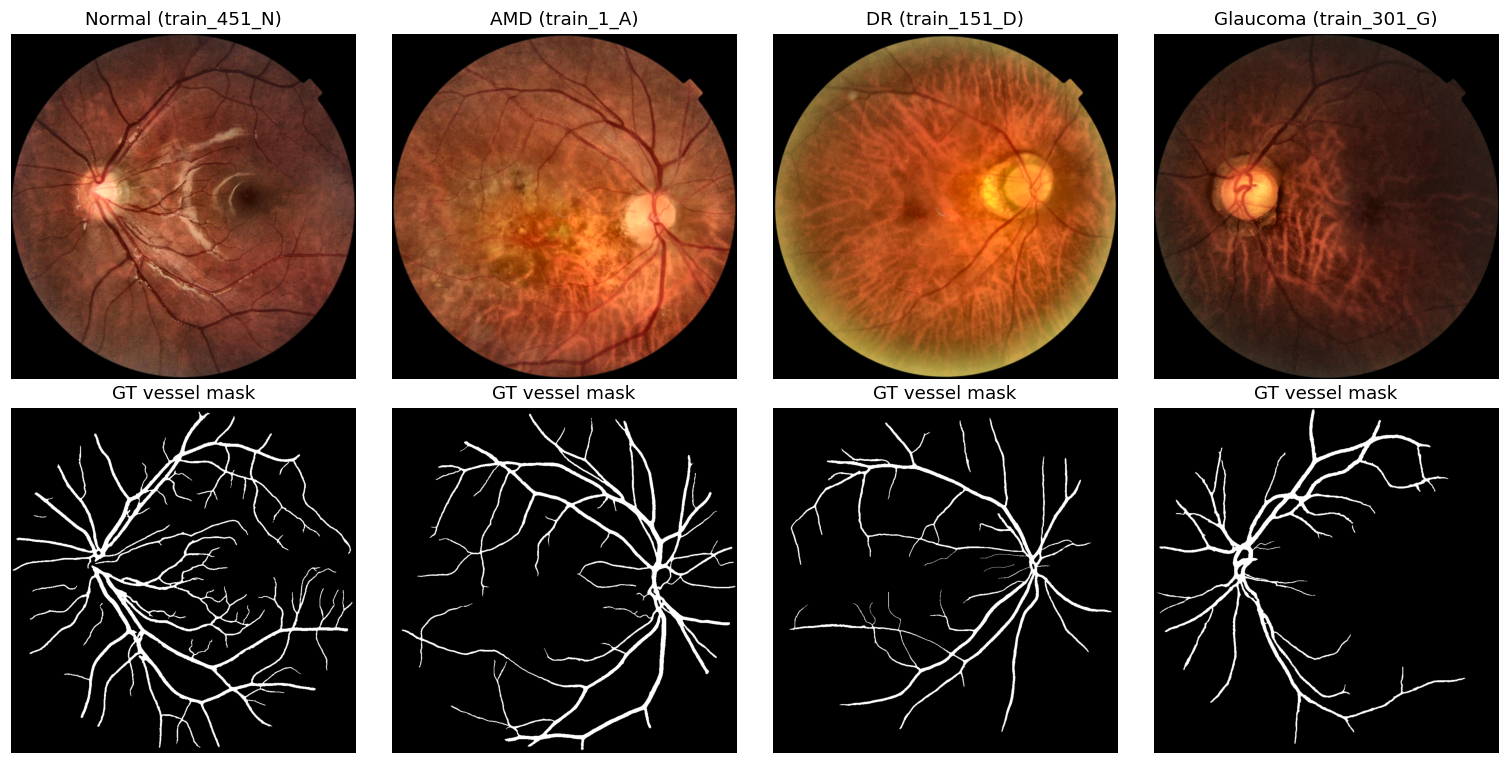

In [5]:
t0 = time.time()
res = Parallel(n_jobs=CFG.N_JOBS)(
    delayed(preprocess)(r['img_path'], r['mask_path']) for r in tqdm(fives.to_dict('records'), desc='FIVES 전처리'))
F_IMG = np.stack([r[0] for r in res])
F_FOV = np.stack([r[1] for r in res])
F_VES = np.stack([r[2] for r in res])
fives = pd.concat([fives, pd.DataFrame([r[3] for r in res])], axis=1)
del res
gc.collect()
print(f'{time.time() - t0:.0f}s | 영상 {F_IMG.shape}, {F_IMG.nbytes / 1e9:.2f} GB')
print('FOV 내 혈관 비율:', round(float(F_VES.sum() / F_FOV.sum()), 4))

# 학습/검증/테스트 인덱스 (공식 test는 그대로, train에서 질환별 층화로 검증셋 분리)
rng = np.random.RandomState(CFG.SEED)
tr_idx, va_idx = [], []
for _, g in fives[fives.split == 'train'].groupby('label'):
    idx = rng.permutation(g.index.values)
    nv = max(1, int(round(len(idx) * CFG.VAL_FRAC)))
    va_idx += idx[:nv].tolist()
    tr_idx += idx[nv:].tolist()
te_idx = fives.index[fives.split == 'test'].tolist()
print(f'train {len(tr_idx)} / val {len(va_idx)} / test {len(te_idx)}')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for j, lab in enumerate(GROUP_ORDER):
    sel = fives.index[(fives.label == lab) & (fives.split == 'train')]
    if len(sel) == 0:
        axes[0, j].axis('off'); axes[1, j].axis('off')
        continue
    k = sel[0]
    axes[0, j].imshow(F_IMG[k]); axes[0, j].set_title(f'{lab} ({fives.id[k]})')
    axes[1, j].imshow(F_VES[k], cmap='gray'); axes[1, j].set_title('GT vessel mask')
for a in axes.ravel():
    a.axis('off')
plt.tight_layout(); savefig('01_fives_examples'); plt.show()

## 2. U-Net 학습

- **모델:** `segmentation_models_pytorch` U-Net + ResNet34 인코더(ImageNet 사전학습)
- **입력:** FOV 안쪽을 중심으로 뽑은 `CROP`×`CROP` 무작위 패치, 추론은 1024 전체 영상
- **손실:** BCE + Dice + **soft clDice**(Shit et al., CVPR 2021). 가는 혈관이 끊기면 세그먼트가 잘게 쪼개져 굴곡도가 왜곡되므로, 중심선 연결성을 직접 최적화합니다.
- **증강:** 반전·회전·약한 아핀·밝기/대비/감마/색조·블러. 탄성 변형은 혈관 모양을 인위적으로 휘게 만들 수 있어 넣지 않았습니다.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
import segmentation_models_pytorch as smp

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
torch.manual_seed(CFG.SEED)
print('device:', DEVICE, '| GPU 수:', torch.cuda.device_count(),
      '|', torch.cuda.get_device_name(0) if USE_AMP else 'CPU (GPU 가속기를 켜세요)')
assert CFG.IMG_SIZE % 32 == 0 and CFG.CROP % 32 == 0

MEAN = np.array([0.485, 0.456, 0.406], np.float32) * 255
STD = np.array([0.229, 0.224, 0.225], np.float32) * 255


def to_tensor(img):
    x = (img.astype(np.float32) - MEAN) / STD
    return torch.from_numpy(np.ascontiguousarray(x.transpose(2, 0, 1)))


train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Affine(rotate=(-20, 20), scale=(0.9, 1.1), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.1),
])


class PatchDS(Dataset):
    # FOV 내부를 중심으로 하는 무작위 패치
    def __init__(self, idx, n_samples, crop, aug=None):
        self.idx, self.n, self.crop, self.aug = np.asarray(idx), n_samples, crop, aug

    def __len__(self):
        return self.n

    def __getitem__(self, i):
        k = self.idx[np.random.randint(len(self.idx))]
        img, ves, fov = F_IMG[k], F_VES[k], F_FOV[k]
        S, c = img.shape[0], self.crop
        for _ in range(20):
            cy, cx = np.random.randint(0, S, 2)
            if fov[cy, cx]:
                break
        y0 = int(np.clip(cy - c // 2, 0, S - c))
        x0 = int(np.clip(cx - c // 2, 0, S - c))
        im = img[y0:y0 + c, x0:x0 + c]
        m = ves[y0:y0 + c, x0:x0 + c].astype(np.uint8)
        if self.aug is not None:
            out = self.aug(image=im, mask=m)
            im, m = out['image'], out['mask']
        return to_tensor(im), torch.from_numpy(m[None].astype(np.float32))


def _worker_init(wid):
    np.random.seed((torch.initial_seed() + wid) % 2 ** 32)

device: cuda | GPU 수: 2 | Tesla T4


In [7]:
# ---- 손실 함수: BCE + Dice + soft clDice ----
def soft_erode(x):
    p1 = -F.max_pool2d(-x, (3, 1), 1, (1, 0))
    p2 = -F.max_pool2d(-x, (1, 3), 1, (0, 1))
    return torch.min(p1, p2)


def soft_dilate(x):
    return F.max_pool2d(x, 3, 1, 1)


def soft_skel(x, iters):
    skel = F.relu(x - soft_dilate(soft_erode(x)))
    for _ in range(iters):
        x = soft_erode(x)
        delta = F.relu(x - soft_dilate(soft_erode(x)))
        skel = skel + F.relu(delta - skel * delta)
    return skel


def dice_loss(p, y, eps=1.0):
    num = 2 * (p * y).sum((1, 2, 3)) + eps
    den = p.sum((1, 2, 3)) + y.sum((1, 2, 3)) + eps
    return (1 - num / den).mean()


def cldice_loss(p, y, iters, eps=1.0):
    sp, sy = soft_skel(p, iters), soft_skel(y, iters)
    tprec = ((sp * y).sum((1, 2, 3)) + eps) / (sp.sum((1, 2, 3)) + eps)
    tsens = ((sy * p).sum((1, 2, 3)) + eps) / (sy.sum((1, 2, 3)) + eps)
    return (1 - 2 * tprec * tsens / (tprec + tsens)).mean()


class VesselLoss(nn.Module):
    def forward(self, logits, y):
        logits = logits.float()                  # AMP에서도 손실은 float32로 계산
        p = torch.sigmoid(logits)
        loss = F.binary_cross_entropy_with_logits(logits, y) + dice_loss(p, y)
        if CFG.CLDICE_W > 0:
            loss = loss + CFG.CLDICE_W * cldice_loss(p, y, CFG.SKEL_ITERS)
        return loss


def build_model(weights='default'):
    w = CFG.ENCODER_WEIGHTS if weights == 'default' else weights
    return smp.Unet(encoder_name=CFG.ENCODER, encoder_weights=w, in_channels=3, classes=1)


def unwrap(m):
    return m.module if isinstance(m, nn.DataParallel) else m


@torch.no_grad()
def forward_tta(model, x, tta=True):
    with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
        p = torch.sigmoid(model(x).float())
        if tta:
            p = p + torch.sigmoid(model(x.flip(-1)).float()).flip(-1)
            p = p + torch.sigmoid(model(x.flip(-2)).float()).flip(-2)
            p = p / 3
    return p[:, 0].float()


@torch.no_grad()
def predict_probs(model, imgs, tta=True, bs=2):
    model.eval()
    out = []
    for i in range(0, len(imgs), bs):
        x = torch.stack([to_tensor(im) for im in imgs[i:i + bs]]).to(DEVICE)
        out.append(forward_tta(model, x, tta).cpu().numpy().astype(np.float16))
    return np.concatenate(out)


def dice_np(pred, gt, fov):
    p, g = pred[fov], gt[fov]
    return 2 * (p & g).sum() / (p.sum() + g.sum() + 1e-8)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

ep   1 | loss 1.9203 | val Dice nan | best -1.0000 | 50s
ep   2 | loss 1.2332 | val Dice 0.7738 | best 0.7738 | 53s
ep   3 | loss 0.8595 | val Dice nan | best 0.7738 | 49s
ep   4 | loss 0.5104 | val Dice 0.8967 | best 0.8967 | 54s
ep   5 | loss 0.3647 | val Dice nan | best 0.8967 | 49s
ep   6 | loss 0.3388 | val Dice 0.9042 | best 0.9042 | 54s
ep   7 | loss 0.3115 | val Dice nan | best 0.9042 | 49s
ep   8 | loss 0.2972 | val Dice 0.9095 | best 0.9095 | 54s
ep   9 | loss 0.2760 | val Dice nan | best 0.9095 | 48s
ep  10 | loss 0.2722 | val Dice 0.9154 | best 0.9154 | 54s
ep  11 | loss 0.2730 | val Dice nan | best 0.9154 | 49s
ep  12 | loss 0.2791 | val Dice 0.9157 | best 0.9157 | 54s
ep  13 | loss 0.2627 | val Dice nan | best 0.9157 | 49s
ep  14 | loss 0.2758 | val Dice 0.9189 | best 0.9189 | 54s
ep  15 | loss 0.2816 | val Dice nan | best 0.9189 | 48s
ep  16 | loss 0.2600 | val Dice 0.9184 | best 0.9189 | 54s
ep  17 | loss 0.2539 | val Dice nan | best 0.9189 | 49s
ep  18 | loss 0.2590 | 

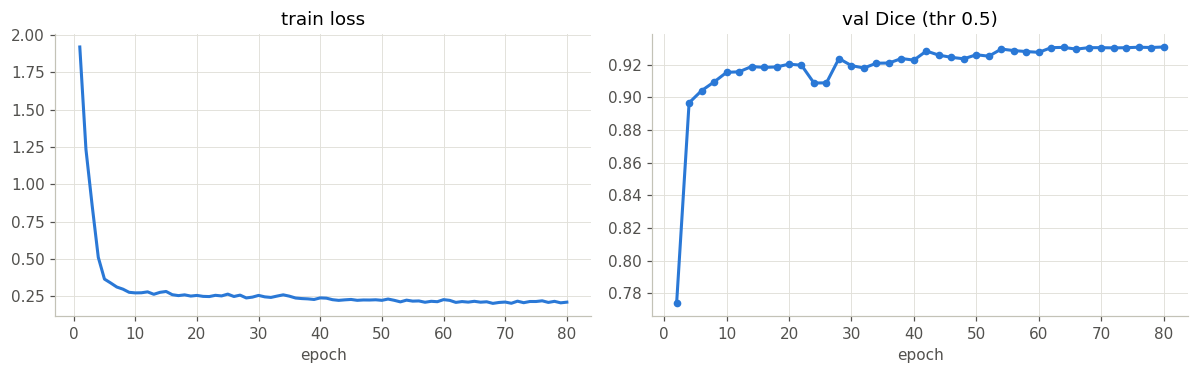

선택된 임계값: 0.6 | val Dice: 0.9336


In [8]:
def train_model():
    model = build_model()
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    model.to(DEVICE)
    dl = DataLoader(PatchDS(tr_idx, CFG.SAMPLES_PER_EPOCH, CFG.CROP, train_aug),
                    batch_size=CFG.BATCH, shuffle=False, num_workers=CFG.NUM_WORKERS,
                    pin_memory=USE_AMP, drop_last=True, worker_init_fn=_worker_init,
                    persistent_workers=CFG.NUM_WORKERS > 0)
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WD)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=CFG.LR, total_steps=CFG.EPOCHS * len(dl),
                                                pct_start=0.05)
    scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)
    crit = VesselLoss()
    best, hist = -1.0, []
    for ep in range(1, CFG.EPOCHS + 1):
        model.train()
        t0, tl = time.time(), 0.0
        for x, y in dl:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                logits = model(x)
            loss = crit(logits, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            sched.step()
            tl += loss.item()
        rec = dict(epoch=ep, train_loss=tl / len(dl))
        if ep % CFG.VAL_EVERY == 0 or ep == CFG.EPOCHS:
            probs = predict_probs(model, F_IMG[va_idx], tta=False)
            rec['val_dice'] = float(np.mean([dice_np(p >= 0.5, F_VES[k], F_FOV[k]) for p, k in zip(probs, va_idx)]))
            if rec['val_dice'] > best:
                best = rec['val_dice']
                torch.save(unwrap(model).state_dict(), CKPT_PATH)
        hist.append(rec)
        print(f"ep {ep:3d} | loss {rec['train_loss']:.4f} | val Dice {rec.get('val_dice', float('nan')):.4f} "
              f"| best {best:.4f} | {time.time() - t0:.0f}s")
    return pd.DataFrame(hist)


if CFG.PRETRAINED_CKPT is not None:
    ckpt = Path(CFG.PRETRAINED_CKPT)
    print('저장된 가중치 사용:', ckpt)
elif CFG.RUN_TRAIN or not CKPT_PATH.exists():
    hist = train_model()
    hist.to_csv(CFG.WORK / 'train_history.csv', index=False)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
    ax[0].plot(hist.epoch, hist.train_loss, color='#2a78d6', lw=2); ax[0].set_title('train loss'); ax[0].set_xlabel('epoch')
    h = hist.dropna(subset=['val_dice'])
    ax[1].plot(h.epoch, h.val_dice, color='#2a78d6', lw=2, marker='o', ms=4); ax[1].set_title('val Dice (thr 0.5)'); ax[1].set_xlabel('epoch')
    plt.tight_layout(); savefig('02_training'); plt.show()
    ckpt = CKPT_PATH
else:
    ckpt = CKPT_PATH

model = build_model(weights=None)
model.load_state_dict(torch.load(ckpt, map_location='cpu'))
model.to(DEVICE).eval()

# 검증셋에서 Dice(=F1)가 최대가 되는 임계값 선택 (TTA 적용)
va_probs = predict_probs(model, F_IMG[va_idx])
ths = np.round(np.arange(0.30, 0.71, 0.05), 2)
th_scores = [np.mean([dice_np(p >= t, F_VES[k], F_FOV[k]) for p, k in zip(va_probs, va_idx)]) for t in ths]
THR = float(ths[int(np.argmax(th_scores))])
print('선택된 임계값:', THR, '| val Dice:', round(max(th_scores), 4))
del va_probs

## 3. FIVES 테스트셋 분할 평가

FOV 내부 픽셀 기준으로 Dice, Sensitivity, Specificity, AUC를 계산하고, 굴곡도 목적에 맞게 **clDice**(중심선 기준 연결성)와 **연결 요소 수 차이**(β0 오차)도 함께 봅니다. 질환군별로 나눠 보면 병변이 분할 오류를 얼마나 유발하는지 알 수 있습니다.

In [9]:
from sklearn.metrics import roc_auc_score

EIGHT = np.ones((3, 3), bool)


def seg_metrics(prob, gt, fov, thr):
    pred = (prob >= thr) & fov
    p, g = pred[fov], gt[fov]
    tp, fp = (p & g).sum(), (p & ~g).sum()
    fn, tn = (~p & g).sum(), (~p & ~g).sum()
    pr = prob[fov].astype(np.float32)
    sel = np.random.RandomState(0).choice(len(pr), min(len(pr), 200_000), replace=False)
    auc = roc_auc_score(g[sel], pr[sel]) if 0 < g[sel].sum() < len(sel) else np.nan
    sp, sg = skeletonize(pred), skeletonize(gt & fov)
    tprec = (sp & gt).sum() / max(sp.sum(), 1)
    tsens = (sg & pred).sum() / max(sg.sum(), 1)
    return dict(dice=2 * tp / (2 * tp + fp + fn + 1e-8), sens=tp / (tp + fn + 1e-8), spec=tn / (tn + fp + 1e-8),
                acc=(tp + tn) / (tp + tn + fp + fn), auc=auc,
                cldice=2 * tprec * tsens / (tprec + tsens + 1e-8),
                betti0_err=abs(ndi.label(pred, EIGHT)[1] - ndi.label(gt & fov, EIGHT)[1]))


te_probs = predict_probs(model, F_IMG[te_idx])
TE_PRED = np.stack([(p >= THR) & F_FOV[k] for p, k in zip(te_probs, te_idx)])
rows = Parallel(n_jobs=CFG.N_JOBS)(delayed(seg_metrics)(p, F_VES[k], F_FOV[k], THR) for p, k in zip(te_probs, te_idx))
seg_eval = pd.concat([fives.loc[te_idx, ['id', 'label']].reset_index(drop=True), pd.DataFrame(rows)], axis=1)
seg_eval.to_csv(CFG.WORK / 'fives_test_segmentation_metrics.csv', index=False)

SEG_COLS = ['dice', 'cldice', 'sens', 'spec', 'auc', 'betti0_err']
summary = seg_eval.groupby('label')[SEG_COLS].mean().reindex([g for g in GROUP_ORDER if g in seg_eval.label.unique()])
summary.loc['전체'] = seg_eval[SEG_COLS].mean()
display(summary.round(4))
groups = [g.dice.values for _, g in seg_eval.groupby('label')]
if len(groups) > 1:
    H, p = stats.kruskal(*groups)
    print(f'질환군 간 Dice 차이 Kruskal-Wallis: H={H:.2f}, p={p:.3g}')

,dice,cldice,sens,spec,auc,betti0_err
label,,,,,,
Normal,0.9174,0.9312,0.8980,0.9929,0.9951,29.480
AMD,0.9335,0.9368,0.9268,0.9937,0.9954,15.980
DR,0.9116,0.9235,0.8932,0.9942,0.9950,14.980
Glaucoma,0.8673,0.8791,0.8542,0.9942,0.9904,12.500
전체,0.9075,0.9177,0.8931,0.9938,0.9940,18.235


질환군 간 Dice 차이 Kruskal-Wallis: H=18.19, p=0.000402


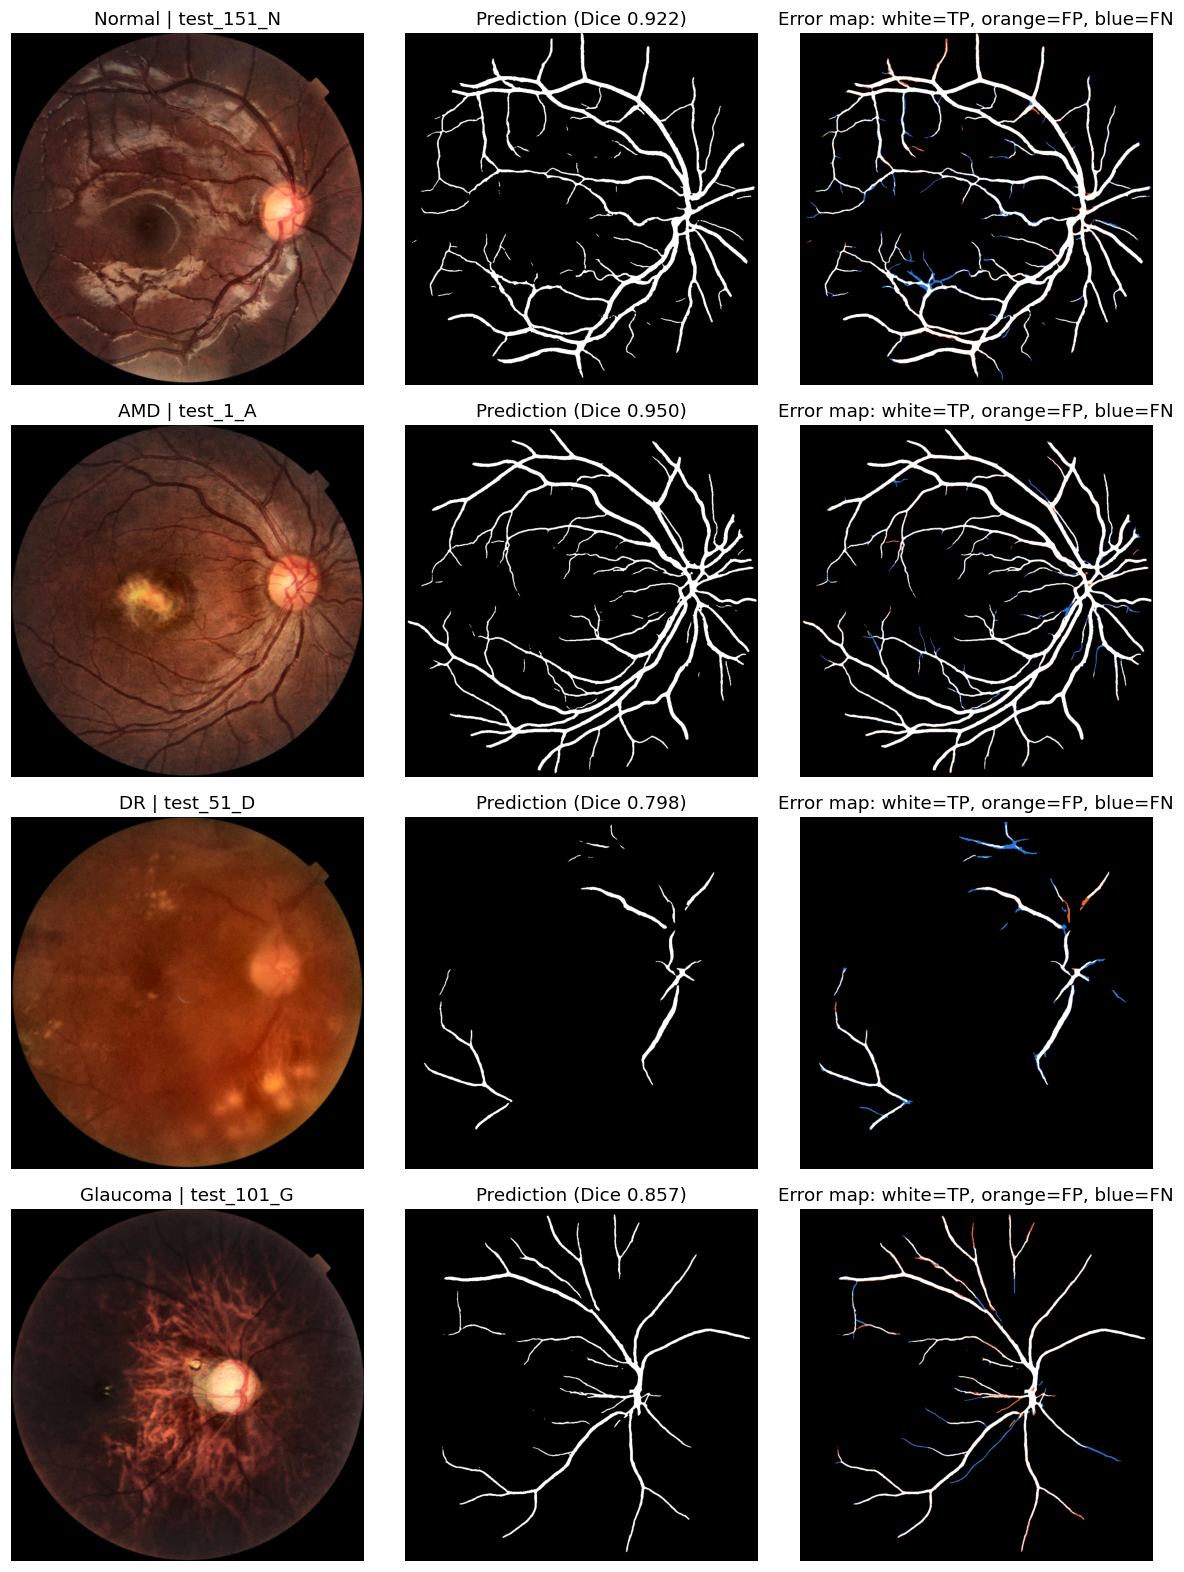

In [10]:
# 질환군별 예시: 흰색=정답과 일치, 주황=과분할(FP), 파랑=누락(FN)
fig, axes = plt.subplots(len(GROUP_ORDER), 3, figsize=(11, 3.6 * len(GROUP_ORDER)))
for i, lab in enumerate(GROUP_ORDER):
    pos = [j for j, k in enumerate(te_idx) if fives.label[k] == lab]
    if not pos:
        for a in axes[i]: a.axis('off')
        continue
    j = pos[0]; k = te_idx[j]
    gt, pr = F_VES[k], TE_PRED[j]
    err = np.zeros(gt.shape + (3,), np.uint8)
    err[gt & pr] = (255, 255, 255)
    err[~gt & pr] = (235, 104, 52)
    err[gt & ~pr] = (42, 120, 214)
    axes[i, 0].imshow(F_IMG[k]); axes[i, 0].set_title(f'{lab} | {fives.id[k]}')
    axes[i, 1].imshow(pr, cmap='gray'); axes[i, 1].set_title(f"Prediction (Dice {seg_eval.dice[j]:.3f})")
    axes[i, 2].imshow(err); axes[i, 2].set_title('Error map: white=TP, orange=FP, blue=FN')
for a in axes.ravel():
    a.axis('off')
plt.tight_layout(); savefig('03_fives_test_examples'); plt.show()

## 4. 스켈레톤 → 혈관 세그먼트 → 굴곡도

1. **정리:** FOV 가장자리 제외, 작은 연결 요소 제거, 작은 구멍 채움
2. **스켈레톤화** 후 **분기점**(주변 8픽셀을 한 바퀴 돌 때 0→1 전이가 3회 이상) 검출
3. 분기점과 그 주변 1픽셀을 제거해 스켈레톤을 **세그먼트**로 나누고, 분기점에 붙은 짧은 **잔가지(spur)** 는 2회 반복 제거
4. 각 세그먼트의 픽셀을 순서대로 정렬(그래프 최장 경로) → **B-spline 평활** → 2px 간격 재샘플. 곡률 기반 지표는 스플라인 경계 효과를 피하려고 양 끝 10px을 빼고 계산
5. 세그먼트별 지표 계산 → 영상 단위 **길이 가중 평균 / 중앙값 / 상위 10%** 로 집계

| 지표 | 정의 | 단위 |
|---|---|---|
| DM | 호 길이 / 현 길이 | 무차원 (1 = 직선) |
| ICM | DM × (변곡점 수 + 1) | 무차원 |
| SOAM | Σ\|방향각 변화\| / 길이 | rad/px |
| CE | ∫κ² ds / 길이 (곡률 에너지) | 1/px² |
| TD | (n−1)/n · (1/L) · Σ(하위 호/현 − 1), n = 변곡점으로 나눈 구간 수 (Grisan 2008) | 1/px |

TD는 정의상 변곡점이 없는 C자형 세그먼트에서 0입니다. 세그먼트 폭(거리 변환 기반)도 저장해 두었다가 민감도 분석에 씁니다.

In [11]:
_OFFS = [(-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1), (-1, -1)]   # N부터 시계 방향
_NB8 = [(dy, dx) for dy in (-1, 0, 1) for dx in (-1, 0, 1) if (dy, dx) != (0, 0)]


def remove_small(mask, min_size):
    lab, n = ndi.label(mask, structure=EIGHT)
    if n == 0:
        return mask
    keep = np.bincount(lab.ravel()) >= min_size
    keep[0] = False
    return keep[lab]


def fill_small_holes(mask, max_size):
    lab, n = ndi.label(~mask)
    if n == 0:
        return mask
    fill = np.bincount(lab.ravel()) < max_size
    fill[0] = False
    return mask | fill[lab]


def clean_vessel_mask(ves, fov, cfg=CFG):
    fov_e = ndi.binary_erosion(fov, iterations=cfg.FOV_ERODE) if cfg.FOV_ERODE else fov
    m = ves & fov_e
    m = remove_small(m, cfg.MIN_OBJ)
    return fill_small_holes(m, cfg.MIN_HOLE)


def neighbor_stack(skel):
    p = np.pad(skel, 1)
    H, W = skel.shape
    return np.stack([p[1 + dy:1 + dy + H, 1 + dx:1 + dx + W] for dy, dx in _OFFS])


def skeleton_nodes(skel):
    nb = neighbor_stack(skel)
    n = nb.sum(0)
    cn = (~nb & np.roll(nb, -1, axis=0)).sum(0)          # 0→1 전이 수 (crossing number)
    junction = skel & ((cn >= 3) | (n >= 4))
    endpoint = skel & (n == 1)
    return junction, endpoint


def _bfs(nbrs, src):
    dist = np.full(len(nbrs), -1)
    prev = np.full(len(nbrs), -1)
    dist[src] = 0
    q = deque([src])
    while q:
        u = q.popleft()
        for v in nbrs[u]:
            if dist[v] < 0:
                dist[v] = dist[u] + 1
                prev[v] = u
                q.append(v)
    return dist, prev


def order_component(pix):
    # 픽셀 집합에서 가장 긴 경로(그래프 지름)를 순서대로 반환
    index = {(y, x): i for i, (y, x) in enumerate(pix.tolist())}
    nbrs = [[index[(y + dy, x + dx)] for dy, dx in _NB8 if (y + dy, x + dx) in index] for y, x in pix.tolist()]
    ends = [i for i, nb in enumerate(nbrs) if len(nb) == 1]
    d, _ = _bfs(nbrs, ends[0] if ends else 0)
    a = int(d.argmax())
    d, prev = _bfs(nbrs, a)
    b = int(d.argmax())
    path = [b]
    while path[-1] != a:
        path.append(int(prev[path[-1]]))
    return pix[path[::-1]]


def extract_segments(skel, cfg=CFG, min_pix=None):
    skel = skel.copy()
    for _ in range(2):                                     # 잔가지 제거 2회
        junc, endp = skeleton_nodes(skel)
        if not junc.any():
            break
        zone = ndi.binary_dilation(junc, structure=EIGHT)      # 분기점 + 주변 8픽셀
        branches = skel & ~zone                                  # (분기점만 빼면 가지끼리 대각선으로 붙을 수 있음)
        lab, n = ndi.label(branches, structure=EIGHT)
        if n == 0:
            break
        near_j = ndi.binary_dilation(zone, structure=EIGHT) & branches
        size = np.bincount(lab.ravel(), minlength=n + 1)
        touches = np.bincount(lab[near_j], minlength=n + 1) > 0
        has_end = np.bincount(lab[endp & branches], minlength=n + 1) > 0
        spur = touches & has_end & (size < cfg.SPUR_LEN)
        spur[0] = False
        if not spur.any():
            break
        skel &= ~spur[lab]
    junc, _ = skeleton_nodes(skel)
    zone = ndi.binary_dilation(junc, structure=EIGHT)
    branches = skel & ~zone
    near_j = ndi.binary_dilation(zone, structure=EIGHT)
    lab, n = ndi.label(branches, structure=EIGHT)
    min_pix = min_pix if min_pix is not None else int(cfg.MIN_SEG_LEN * 0.6)
    segs = []
    for l, sl in enumerate(ndi.find_objects(lab), start=1):
        if sl is None:
            continue
        ys, xs = np.nonzero(lab[sl] == l)
        if len(ys) < min_pix:
            continue
        pix = np.c_[ys + sl[0].start, xs + sl[1].start]
        path = order_component(pix)
        n_junc_ends = int(near_j[tuple(path[0])]) + int(near_j[tuple(path[-1])])
        segs.append(dict(coords=path, n_junction_ends=n_junc_ends))
    return segs

In [12]:
METRICS = ['DM', 'ICM', 'SOAM', 'CE', 'TD']


def _spline(coords, cfg=CFG):
    pts = coords[:, ::-1].astype(np.float64)                     # (x, y)
    keep = np.r_[True, np.any(np.diff(pts, axis=0) != 0, axis=1)]
    pts = pts[keep]
    if len(pts) < 6:
        return None
    u = np.r_[0, np.cumsum(np.hypot(*np.diff(pts, axis=0).T))]
    u /= u[-1]
    try:
        tck, _ = splprep(pts.T, u=u, s=cfg.SPLINE_S * len(pts), k=3)
    except Exception:
        return None
    dense = np.linspace(0, 1, max(400, 4 * len(pts)))
    x, y = splev(dense, tck)
    arc = np.r_[0, np.cumsum(np.hypot(np.diff(x), np.diff(y)))]
    L = arc[-1]
    n = max(int(L / cfg.STEP), 8)
    return tck, np.interp(np.linspace(0, L, n + 1), arc, dense), L


def segment_tortuosity(coords, cfg=CFG):
    r = _spline(coords, cfg)
    if r is None:
        return None
    tck, u, L = r
    x, y = splev(u, tck)
    dx, dy = splev(u, tck, der=1)
    ddx, ddy = splev(u, tck, der=2)
    kappa = (dx * ddy - dy * ddx) / (np.hypot(dx, dy) ** 3 + 1e-12)
    ds = L / (len(u) - 1)
    chord = float(np.hypot(x[-1] - x[0], y[-1] - y[0]))
    DM = L / max(chord, 1e-6)

    # 곡률 기반 지표는 양 끝(스플라인 경계 효과)을 제외한 내부 구간에서 계산
    e = min(cfg.END_TRIM, (len(u) - 1) // 4)
    inner = slice(e, len(u) - e)
    k_in = kappa[inner]
    L_in = ds * (len(k_in) - 1)

    # 변곡점: |κ| > KAPPA_MIN 인 같은 부호 구간이 MIN_RUN 이상 이어진 것들 사이의 부호 변화
    sgn = np.where(np.abs(k_in) > cfg.KAPPA_MIN, np.sign(k_in), 0)
    runs, i = [], 0
    while i < len(sgn):
        if sgn[i] == 0:
            i += 1
            continue
        j = i
        while j + 1 < len(sgn) and sgn[j + 1] == sgn[i]:
            j += 1
        if j - i + 1 >= cfg.MIN_RUN:
            if runs and runs[-1][0] == sgn[i]:
                runs[-1] = (sgn[i], runs[-1][1], j)
            else:
                runs.append((sgn[i], i, j))
        i = j + 1
    infl = [e + (runs[k][2] + runs[k + 1][1]) // 2 for k in range(len(runs) - 1)]

    theta = np.unwrap(np.arctan2(dy[inner], dx[inner]))
    SOAM = float(np.abs(np.diff(theta)).sum() / L_in)
    CE = float(np.sum(k_in ** 2) * ds / L_in)

    xy = np.c_[x, y]
    bounds = [0] + infl + [len(u) - 1]
    n_sub = len(bounds) - 1
    acc = 0.0
    for a, b in zip(bounds[:-1], bounds[1:]):
        if b - a < 1:
            continue
        la = np.hypot(*np.diff(xy[a:b + 1], axis=0).T).sum()
        acc += la / max(np.hypot(*(xy[b] - xy[a])), 1e-6) - 1
    TD = (n_sub - 1) / n_sub * acc / L if n_sub > 1 else 0.0
    return dict(length=float(L), chord=chord, DM=float(DM), n_infl=len(infl),
                ICM=float(DM * (len(infl) + 1)), SOAM=SOAM, CE=CE, TD=float(TD),
                cx=float(x.mean()), cy=float(y.mean()))


def image_tortuosity(ves_bin, fov, cfg=CFG, return_lines=False):
    m = clean_vessel_mask(ves_bin, fov, cfg)
    skel = skeletonize(m)
    segs = extract_segments(skel, cfg)
    dt = ndi.distance_transform_edt(m)
    rows, lines = [], []
    for s in segs:
        c = s['coords']
        t = segment_tortuosity(c, cfg)
        if t is None or t['length'] < cfg.MIN_SEG_LEN:
            continue
        t['width'] = float(2 * dt[c[:, 0], c[:, 1]].mean() - 1)       # 중심선 거리변환 기반 폭
        t['n_junction_ends'] = s['n_junction_ends']
        rows.append(t)
        lines.append(c)
    seg = pd.DataFrame(rows, columns=['length', 'chord', 'DM', 'n_infl', 'ICM', 'SOAM', 'CE', 'TD',
                                      'cx', 'cy', 'width', 'n_junction_ends'])
    info = dict(vessel_density=float(m.sum() / max(fov.sum(), 1)), skel_len_px=int(skel.sum()))
    return (seg, info, lines) if return_lines else (seg, info)


def aggregate_segments(seg, min_len=None, min_width=None):
    s = seg
    if min_len is not None:
        s = s[s['length'] >= min_len]
    if min_width is not None:
        s = s[s['width'] >= min_width]
    out = {'n_seg': len(s), 'total_len': float(s['length'].sum()) if len(s) else 0.0}
    for m in METRICS:
        if len(s) == 0:
            out[f'{m}_lw'] = out[f'{m}_med'] = out[f'{m}_p90'] = np.nan
            continue
        v, w = s[m].values, s['length'].values
        out[f'{m}_lw'] = float(np.average(v, weights=w))
        out[f'{m}_med'] = float(np.median(v))
        out[f'{m}_p90'] = float(np.percentile(v, 90))
    return out


def run_tortuosity(masks, fovs, ids, n_jobs=None):
    res = Parallel(n_jobs=n_jobs or CFG.N_JOBS)(
        delayed(image_tortuosity)(m, f) for m, f in tqdm(zip(masks, fovs), total=len(ids), desc='굴곡도'))
    segs, rows = [], []
    for i, (seg, info) in zip(ids, res):
        if len(seg):
            segs.append(seg.assign(image_id=i))
        rows.append({'image_id': i, **info, **aggregate_segments(seg)})
    return (pd.concat(segs, ignore_index=True) if segs else pd.DataFrame()), pd.DataFrame(rows)

### 굴곡도 계산 검증 (합성 곡선)

실제 데이터에 쓰기 전에 모양을 아는 곡선으로 확인합니다. 직선은 DM≈1·변곡점 0, 원호는 곡률 ≈ 1/반지름, 사인파는 진폭이 커질수록 모든 지표가 증가하고 변곡점 수가 반주기 수와 맞아야 합니다. 마지막 표는 굵은 혈관 모양을 그린 마스크에 전체 파이프라인(스켈레톤 → 세그먼트 → 지표)을 적용한 결과입니다.

In [13]:
def _curve_pixels(x, y):
    # 연속 곡선 → 끊김 없는 8-연결 픽셀 좌표 (row, col)
    xs = np.interp(np.linspace(0, len(x) - 1, len(x) * 4), np.arange(len(x)), x)
    ys = np.interp(np.linspace(0, len(y) - 1, len(y) * 4), np.arange(len(y)), y)
    pix = np.c_[np.round(ys), np.round(xs)].astype(int)
    keep = np.r_[True, np.any(np.diff(pix, axis=0) != 0, axis=1)]
    return pix[keep]


t = np.linspace(0, 1, 400)
tests = {
    '직선 0°': (t * 300, t * 0 + 50),
    '직선 30°': (t * 300 * np.cos(0.52), t * 300 * np.sin(0.52)),
    '원호 R=100 (κ=0.01)': (100 * np.cos(t * 2.5), 100 * np.sin(t * 2.5)),
}
for amp in (3, 8, 15, 25):
    tests[f'사인 진폭 {amp}px, 3주기'] = (t * 300, 50 + amp * np.sin(2 * np.pi * 3 * t))

rows = []
for name, (x, y) in tests.items():
    pix = _curve_pixels(x + 150, y + 150)
    r = segment_tortuosity(pix)
    kap = r['CE'] ** 0.5
    rows.append({'곡선': name, **{k: r[k] for k in ['length', 'DM', 'n_infl', 'ICM', 'SOAM', 'CE', 'TD']},
                 'RMS 곡률': kap})
display(pd.DataFrame(rows).set_index('곡선').round(4))

# 굵은 혈관 모양 마스크에 전체 파이프라인 적용
S = 512
canvas = np.zeros((S, S), np.uint8)
yy, xx = np.mgrid[:S, :S]
fov_syn = (yy - S / 2) ** 2 + (xx - S / 2) ** 2 < (S / 2 - 5) ** 2
for k, amp in enumerate([0, 6, 14, 24]):
    xs = np.linspace(60, 450, 300)
    ys = 90 + k * 110 + amp * np.sin(2 * np.pi * 3 * (xs - 60) / 390)
    pts = np.c_[xs, ys].round().astype(np.int32)
    cv2.polylines(canvas, [pts], False, 255, thickness=5)
cv2.line(canvas, (256, 90), (256, 420), 255, 3)          # 분기점을 만드는 수직 혈관
seg_syn, info_syn = image_tortuosity(canvas > 0, fov_syn, cfg=type('C', (CFG,), {'FOV_ERODE': 0}))
display(seg_syn.sort_values('cy')[['cy', 'length', 'DM', 'n_infl', 'SOAM', 'TD', 'width', 'n_junction_ends']].round(3))

,length,DM,n_infl,ICM,SOAM,CE,TD,RMS 곡률
곡선,,,,,,,,
직선 0°,300.0000,1.0000,0,1.0000,0.0000,0.0000,0.0000,0.0000
직선 30°,301.5224,1.0000,0,1.0000,0.0000,0.0000,0.0000,0.0000
원호 R=100 (κ=0.01),248.0352,1.3098,0,1.3098,0.0099,0.0001,0.0000,0.0101
"사인 진폭 3px, 3주기",302.9893,1.0070,1,2.0140,0.0063,0.0001,0.0000,0.0074
"사인 진폭 8px, 3주기",319.2138,1.0614,5,6.3685,0.0188,0.0004,0.0010,0.0206
"사인 진폭 15px, 3주기",355.4800,1.1920,5,7.1519,0.0281,0.0010,0.0027,0.0317
"사인 진폭 25px, 3주기",434.8232,1.4492,5,8.6949,0.0303,0.0015,0.0051,0.0391


,cy,length,DM,n_infl,SOAM,TD,width,n_junction_ends
0,90.051,187.480,1.000,0,0.000,0.000,6.896,1
1,90.051,187.480,1.000,0,0.000,0.000,6.896,1
2,145.000,104.000,1.000,0,0.000,0.000,5.003,2
4,198.472,197.967,1.020,2,0.008,0.000,5.957,1
3,201.012,197.035,1.020,2,0.008,0.000,5.969,1
5,254.000,102.000,1.000,0,0.000,0.000,5.000,2
7,306.915,210.577,1.103,2,0.018,0.001,5.865,1
6,312.679,214.575,1.108,2,0.018,0.001,5.849,1
8,363.000,98.000,1.000,0,0.000,0.000,5.000,2
10,415.031,239.400,1.276,2,0.024,0.002,5.943,1


## 5. FIVES: 편향 점검과 질환군 비교

**5-1. 정답 vs 예측 굴곡도 (테스트 200장).** 같은 영상에서 정답 마스크와 예측 마스크로 각각 굴곡도를 계산해 ICC(2,1, 절대 일치), Spearman 상관, Bland-Altman으로 비교합니다. 이어서 **(예측 − 정답) 차이가 질환군마다 다른지** 검정합니다. DR군에서만 차이가 크게 나오면, 외부 데이터에서 보이는 DR 등급–굴곡도 관계의 일부가 분할 오류에서 왔을 수 있다는 뜻입니다.

**5-2. 정답 기준 질환군 비교 (800장 전체).** 정답 마스크만 쓰므로 분할 오류가 섞이지 않은 기준선입니다.

굴곡도:   0%|          | 0/800 [00:00<?, ?it/s]

굴곡도:   0%|          | 0/200 [00:00<?, ?it/s]

GT 영상당 세그먼트 수 중앙값: 97.0 | 예측: 84.5


,"ICC(2,1)",Spearman ρ,평균 차이(예측−정답),차이[Normal],차이[AMD],차이[DR],차이[Glaucoma],군간 차이 p (KW),군간 차이 p (Holm)
지표,,,,,,,,,
DM_lw,0.3304,0.7171,-0.0003,-0.0026,0.0008,0.0007,-0.0002,0.1266,0.2532
ICM_lw,0.4259,0.7004,-0.0053,-0.0242,0.0555,0.0217,-0.0743,0.3043,0.3043
SOAM_lw,0.8305,0.9017,-0.0006,-0.0008,-0.0004,-0.0004,-0.0008,0.0014,0.0056
CE_lw,0.6528,0.8251,-0.0000,-0.0001,-0.0000,-0.0000,-0.0000,0.0007,0.0033
TD_lw,0.6707,0.8179,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0039,0.0117


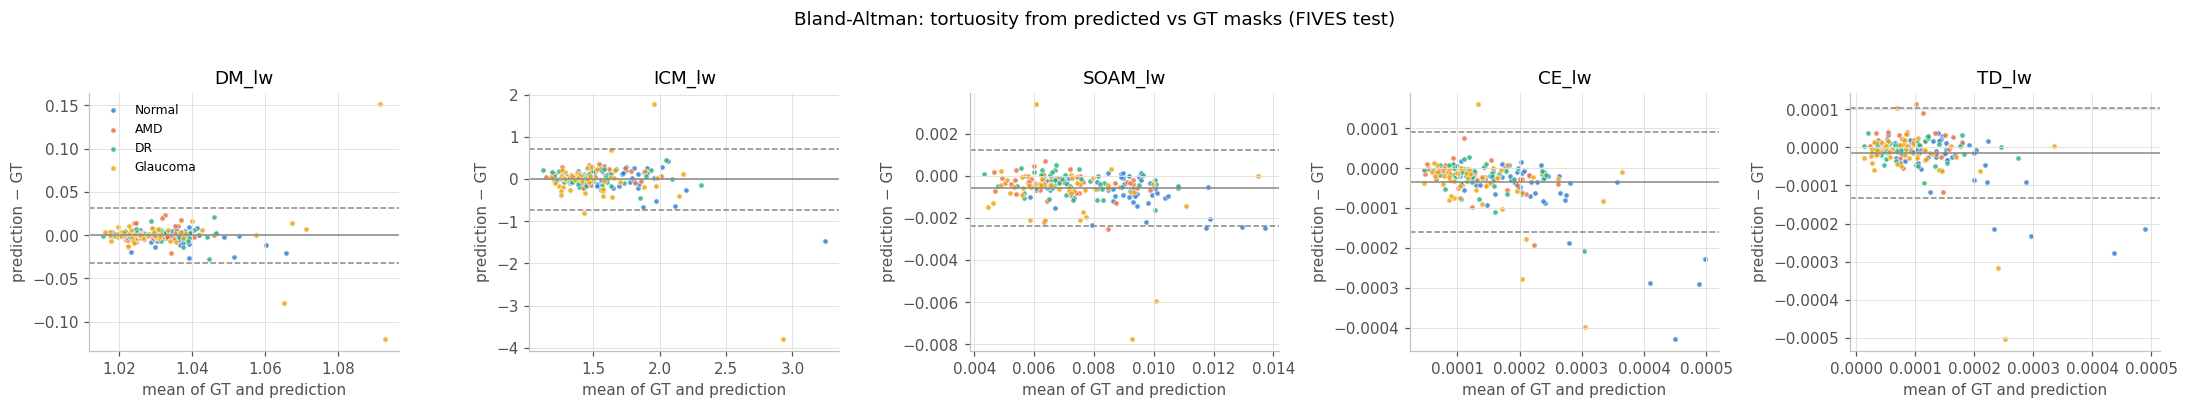

In [14]:
gt_seg, gt_img = run_tortuosity(F_VES, F_FOV, fives.id.tolist())
gt_img = gt_img.merge(fives[['id', 'label', 'split', 'blur', 'bright']], left_on='image_id', right_on='id').drop(columns='id')
pr_seg, pr_img = run_tortuosity(TE_PRED, F_FOV[te_idx], fives.id[te_idx].tolist())
gt_seg.to_csv(CFG.WORK / 'fives_gt_segments.csv.gz', index=False)
gt_img.to_csv(CFG.WORK / 'fives_gt_image_tortuosity.csv', index=False)
pr_img.to_csv(CFG.WORK / 'fives_test_pred_image_tortuosity.csv', index=False)
print('GT 영상당 세그먼트 수 중앙값:', gt_img.n_seg.median(), '| 예측:', pr_img.n_seg.median())


def icc_2_1(a, b):
    X = np.c_[a, b]
    X = X[~np.isnan(X).any(1)]
    n, k = X.shape
    gm = X.mean()
    msr = k * ((X.mean(1) - gm) ** 2).sum() / (n - 1)
    msc = n * ((X.mean(0) - gm) ** 2).sum() / (k - 1)
    sse = ((X - X.mean(1, keepdims=True) - X.mean(0, keepdims=True) + gm) ** 2).sum()
    mse = sse / ((n - 1) * (k - 1))
    return (msr - mse) / (msr + (k - 1) * mse + k * (msc - mse) / n)


def holm(p):
    p = np.asarray(p, float)
    out = np.full(len(p), np.nan)
    ok = ~np.isnan(p)
    idx = np.where(ok)[0][np.argsort(p[ok])]
    m, run = len(idx), 0.0
    for r, i in enumerate(idx):
        run = max(run, (m - r) * p[i])
        out[i] = min(run, 1.0)
    return out


LW = [f'{m}_lw' for m in METRICS]
cmp = gt_img[gt_img.split == 'test'][['image_id', 'label'] + LW].merge(
    pr_img[['image_id'] + LW], on='image_id', suffixes=('_gt', '_pred'))
rows = []
for m in LW:
    a, b = cmp[f'{m}_gt'].values, cmp[f'{m}_pred'].values
    d = b - a
    by = cmp.assign(d=d).groupby('label').d
    kw = stats.kruskal(*[g.dropna().values for _, g in by]) if cmp.label.nunique() > 1 else (np.nan, np.nan)
    rows.append({'지표': m, 'ICC(2,1)': icc_2_1(a, b), 'Spearman ρ': stats.spearmanr(a, b, nan_policy='omit')[0],
                 '평균 차이(예측−정답)': np.nanmean(d),
                 **{f'차이[{g}]': by.mean().get(g, np.nan) for g in GROUP_ORDER},
                 '군간 차이 p (KW)': kw[1]})
agree = pd.DataFrame(rows).set_index('지표')
agree['군간 차이 p (Holm)'] = holm(agree['군간 차이 p (KW)'])
agree.to_csv(CFG.WORK / 'fives_gt_vs_pred_agreement.csv')
display(agree.round(4))

fig, axes = plt.subplots(1, len(LW), figsize=(4 * len(LW), 3.6))
for ax, m in zip(axes, LW):
    a, b = cmp[f'{m}_gt'], cmp[f'{m}_pred']
    mean, diff = (a + b) / 2, b - a
    for g in GROUP_ORDER:
        s = cmp.label == g
        ax.scatter(mean[s], diff[s], s=12, color=GROUP_COLORS[g], label=g, alpha=0.8,
                   edgecolor='#fcfcfb', linewidth=0.5)
    md_, sd = np.nanmean(diff), np.nanstd(diff)
    for v, ls in [(md_, '-'), (md_ + 1.96 * sd, '--'), (md_ - 1.96 * sd, '--')]:
        ax.axhline(v, color='#898781', ls=ls, lw=1)
    ax.set_title(m); ax.set_xlabel('mean of GT and prediction'); ax.set_ylabel('prediction − GT')
axes[0].legend(fontsize=8, frameon=False)
plt.suptitle('Bland-Altman: tortuosity from predicted vs GT masks (FIVES test)', y=1.02)
plt.tight_layout(); savefig('05_bland_altman'); plt.show()

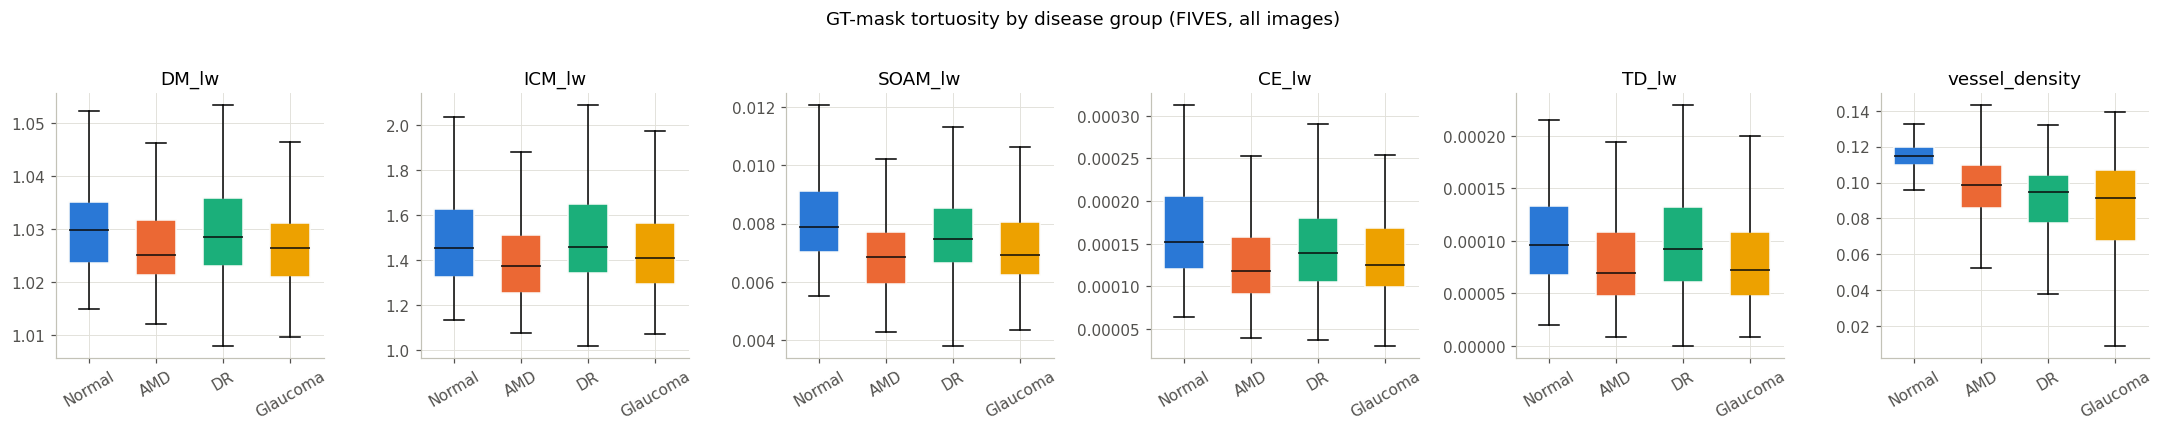

,KW H,KW p,AMD vs Normal p,DR vs Normal p,Glaucoma vs Normal p,AMD vs Normal p(Holm),DR vs Normal p(Holm),Glaucoma vs Normal p(Holm)
지표,,,,,,,,
DM_lw,22.9951,0.0,0.0001,0.4646,0.0003,0.0006,1.0000,0.0020
ICM_lw,26.0071,0.0,0.0001,0.3930,0.0949,0.0006,1.0000,0.3795
SOAM_lw,72.1910,0.0,0.0000,0.0042,0.0000,0.0000,0.0211,0.0000
CE_lw,45.9276,0.0,0.0000,0.0020,0.0000,0.0000,0.0123,0.0000
TD_lw,37.6310,0.0,0.0000,0.3420,0.0000,0.0000,1.0000,0.0001
vessel_density,230.6071,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


,DM_lw,ICM_lw,SOAM_lw,CE_lw,TD_lw,vessel_density,n_seg
label,,,,,,,
Normal,1.0297,1.4528,0.0079,0.0002,0.0001,0.1147,113.0
AMD,1.0251,1.3750,0.0069,0.0001,0.0001,0.0984,97.0
DR,1.0285,1.4571,0.0075,0.0001,0.0001,0.0946,80.0
Glaucoma,1.0264,1.4106,0.0069,0.0001,0.0001,0.0915,86.0


In [15]:
# 5-2. 정답 마스크 기준 질환군 비교 (800장)
labs = [g for g in GROUP_ORDER if g in gt_img.label.unique()]
fig, axes = plt.subplots(1, len(LW) + 1, figsize=(3.3 * (len(LW) + 1), 3.8))
rows = []
for ax, m in zip(axes, LW + ['vessel_density']):
    data = [gt_img.loc[gt_img.label == g, m].dropna().values for g in labs]
    bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.6, medianprops=dict(color='#0b0b0b'))
    for patch, g in zip(bp['boxes'], labs):
        patch.set_facecolor(GROUP_COLORS[g]); patch.set_edgecolor('#fcfcfb')
    ax.set_xticks(range(1, len(labs) + 1)); ax.set_xticklabels(labs, rotation=30)
    ax.set_title(m)
    H, p = stats.kruskal(*data)
    row = {'지표': m, 'KW H': H, 'KW p': p}
    if 'Normal' in labs:
        for g in labs:
            if g != 'Normal':
                row[f'{g} vs Normal p'] = stats.mannwhitneyu(data[labs.index(g)], data[labs.index('Normal')]).pvalue
    rows.append(row)
plt.suptitle('GT-mask tortuosity by disease group (FIVES, all images)', y=1.02)
plt.tight_layout(); savefig('05_fives_group_comparison'); plt.show()

grp = pd.DataFrame(rows).set_index('지표')
pcols = [c for c in grp.columns if c.endswith('vs Normal p')]
if pcols:                                                   # 지표×비교 전체에 Holm 보정
    flat = holm(grp[pcols].values.ravel())
    grp[[c.replace(' p', ' p(Holm)') for c in pcols]] = flat.reshape(grp[pcols].shape)
display(grp.round(4))
display(gt_img.groupby('label')[LW + ['vessel_density', 'n_seg']].median().reindex(labs).round(4))

### 5-3. 결과 저장

가중치, FIVES 결과, 임계값·설정값(`run_info.json`)을 확인하고 `fives_results.zip`으로 묶습니다. Save Version으로 실행하면 이 파일들이 버전 출력에 영구 저장됩니다. 이후 APTOS 분석에 쓰지 않는 FIVES 영상 배열은 메모리에서 비웁니다.

In [16]:
import json, zipfile, time
from IPython.display import FileLink, display

W = CFG.WORK
W.mkdir(parents=True, exist_ok=True)

# 1) 파일이 없으면 메모리에 남아 있는 모델·결과로 다시 저장
ckpt_file = W / 'unet_fives_best.pt'
if not ckpt_file.exists():
    torch.save(unwrap(model).state_dict(), ckpt_file)
    print('가중치를 메모리의 모델로 다시 저장했습니다:', ckpt_file.name)

tables = {
    'fives_test_segmentation_metrics.csv': ('seg_eval', dict(index=False)),
    'fives_gt_image_tortuosity.csv': ('gt_img', dict(index=False)),
    'fives_gt_segments.csv.gz': ('gt_seg', dict(index=False)),
    'fives_test_pred_image_tortuosity.csv': ('pr_img', dict(index=False)),
    'fives_gt_vs_pred_agreement.csv': ('agree', dict()),
}
for fname, (var, kw) in tables.items():
    if not (W / fname).exists() and var in globals():
        globals()[var].to_csv(W / fname, **kw)
        print('다시 저장:', fname)

# 2) 2차 노트북에 필요한 실행 정보 (임계값, 설정값, 핵심 결과)
cfg_values = {k: (str(v) if isinstance(v, Path) else v) for k, v in vars(CFG).items()
              if not k.startswith('_') and isinstance(v, (int, float, str, bool, Path, type(None)))}
run_info = {
    'THR': float(THR),
    'saved_at': time.strftime('%Y-%m-%d %H:%M'),
    'cfg': cfg_values,
    'test_dice_mean': float(seg_eval['dice'].mean()) if 'seg_eval' in globals() else None,
    'test_dice_by_group': seg_eval.groupby('label')['dice'].mean().round(4).to_dict() if 'seg_eval' in globals() else None,
    'icc': agree['ICC(2,1)'].round(4).to_dict() if 'agree' in globals() else None,
}
(W / 'run_info.json').write_text(json.dumps(run_info, ensure_ascii=False, indent=2), encoding='utf-8')
print('실행 정보 저장: run_info.json (임계값', run_info['THR'], ')')

# 3) 저장된 파일 확인
need = ['unet_fives_best.pt', 'fives_gt_vs_pred_agreement.csv', 'run_info.json']
print('\n2차 노트북에 꼭 필요한 파일')
for f in need:
    p = W / f
    print(f"  {'OK ' if p.exists() else '없음'}  {f}  ({p.stat().st_size / 1e6:.1f} MB)" if p.exists() else f'  없음  {f}')

# 4) 전부 하나의 zip으로 묶기 (가중치 + CSV + JSON + 그림)
zip_path = W / 'fives_results.zip'
files = [p for p in sorted(W.rglob('*')) if p.is_file() and p != zip_path]
with zipfile.ZipFile(zip_path, 'w') as zf:
    for p in files:
        method = zipfile.ZIP_STORED if p.suffix in ('.pt', '.gz', '.png') else zipfile.ZIP_DEFLATED
        zf.write(p, p.relative_to(W), compress_type=method)
print(f'\n묶음 파일: {zip_path.name} ({zip_path.stat().st_size / 1e6:.1f} MB, {len(files)}개 파일)')

# 5) 내려받기 링크 (클릭하면 내 컴퓨터로 다운로드)
os.chdir(W)
display(FileLink('fives_results.zip'))
display(FileLink('unet_fives_best.pt'))

# APTOS 분석 전에 메모리 정리
for _v in ['F_IMG', 'te_probs', 'res']:
    globals().pop(_v, None)
gc.collect()

실행 정보 저장: run_info.json (임계값 0.6 )

2차 노트북에 꼭 필요한 파일
  OK   unet_fives_best.pt  (97.9 MB)
  OK   fives_gt_vs_pred_agreement.csv  (0.0 MB)
  OK   run_info.json  (0.0 MB)

묶음 파일: fives_results.zip (108.0 MB, 14개 파일)


/kaggle/working/fives_results.zip

/kaggle/working/unet_fives_best.pt

50154

## 6. APTOS 2019: 추론 → 굴곡도

학습한 U-Net으로 APTOS 영상의 혈관을 분할하고 굴곡도를 계산합니다. 결과는 200장마다 CSV에 추가 저장되므로, 세션이 끊겨도 다시 실행하면 처리한 영상은 건너뛰고 이어서 진행합니다.

**측정 신뢰도:** APTOS에는 혈관 정답이 없으므로, 5-1에서 구한 **FIVES 정답–예측 일치도(ICC)** 를 지표별 신뢰도로 결과 표에 함께 표시합니다 (0.75 이상 좋음, 0.5–0.75 보통, 0.5 미만 낮음).

In [17]:
LW = [f'{m}_lw' for m in METRICS]
ICC = agree['ICC(2,1)'].to_dict()


def icc_label(v):
    if v is None or pd.isna(v):
        return '정보 없음'
    return '좋음' if v >= 0.75 else ('보통' if v >= 0.5 else '낮음')


rel = pd.DataFrame({'지표': LW, 'FIVES ICC': [ICC.get(m, np.nan) for m in LW]})
rel['신뢰도'] = rel['FIVES ICC'].map(icc_label)
display(rel.set_index('지표').round(3))

,FIVES ICC,신뢰도
지표,,
DM_lw,0.330,낮음
ICM_lw,0.426,낮음
SOAM_lw,0.830,좋음
CE_lw,0.653,보통
TD_lw,0.671,보통


In [18]:
from torch.utils.data import Dataset, DataLoader


class InferDS(Dataset):
    def __init__(self, table):
        self.t = table.reset_index(drop=True)

    def __len__(self):
        return len(self.t)

    def __getitem__(self, i):
        r = self.t.iloc[i]
        try:
            img, fov, _, info = preprocess(r['path'])
        except Exception as e:
            print('건너뜀:', r['image_id'], e)
            return None
        return to_tensor(img), img, fov, info, r['image_id']


def _collate(batch):
    batch = [b for b in batch if b is not None]
    if not batch:
        return None
    x, imgs, fovs, infos, ids = zip(*batch)
    return torch.stack(x), list(imgs), list(fovs), list(infos), list(ids)


def _append_csv(df, path):
    if len(df):
        df.to_csv(path, mode='a', header=not Path(path).exists(), index=False)


def process_aptos(table, max_n=None, qc_per_grade=2):
    out_img = CFG.WORK / 'aptos_image_tortuosity.csv'
    out_seg = CFG.WORK / 'aptos_segments.csv.gz'
    done = set(pd.read_csv(out_img).image_id.astype(str)) if out_img.exists() else set()
    todo = table[~table.image_id.isin(done)]
    if max_n is not None:
        todo = todo.head(max(0, max_n - len(done)))
    print(f'완료 {len(done)}장 / 이번에 처리 {len(todo)}장')
    grade_of = dict(zip(table.image_id, table.grade))
    qc = {}
    if len(todo):
        dl = DataLoader(InferDS(todo), batch_size=CFG.INFER_BATCH, num_workers=CFG.NUM_WORKERS, collate_fn=_collate)
        buf_img, buf_seg = [], []
        t0 = time.time()
        with Parallel(n_jobs=CFG.N_JOBS) as par:
            for batch in tqdm(dl, desc='APTOS'):
                if batch is None:
                    continue
                x, imgs, fovs, infos, ids = batch
                probs = forward_tta(model, x.to(DEVICE)).cpu().numpy()
                bins = [(p >= THR) & f for p, f in zip(probs, fovs)]
                res = par(delayed(image_tortuosity)(b, f) for b, f in zip(bins, fovs))
                for iid, info, (seg, tinfo), im, b, f in zip(ids, infos, res, imgs, bins, fovs):
                    buf_img.append({'image_id': iid, **info, **tinfo, **aggregate_segments(seg)})
                    if len(seg):
                        buf_seg.append(seg.assign(image_id=iid))
                    g = grade_of[iid]
                    if len(qc.setdefault(g, [])) < qc_per_grade:
                        qc[g].append((iid, im, b, f))
                if len(buf_img) >= 200:
                    _append_csv(pd.DataFrame(buf_img), out_img)
                    if buf_seg:
                        _append_csv(pd.concat(buf_seg), out_seg)
                    buf_img, buf_seg = [], []
        _append_csv(pd.DataFrame(buf_img), out_img)
        if buf_seg:
            _append_csv(pd.concat(buf_seg), out_seg)
        print(f'{(time.time() - t0) / 60:.1f}분 소요')
    img_df = pd.read_csv(out_img, dtype={'image_id': str}).drop_duplicates('image_id', keep='last')
    img_df = img_df.merge(table[['image_id', 'grade']], on='image_id')
    seg_df = pd.read_csv(out_seg, dtype={'image_id': str}) if out_seg.exists() else pd.DataFrame(columns=['image_id'])
    return img_df, seg_df, qc


APTOS_ROOT = CFG.APTOS_ROOT
if not (APTOS_ROOT / 'train.csv').exists():
    raise FileNotFoundError('APTOS를 찾지 못했습니다. Add Input → Competitions에서 '
                            'APTOS 2019 Blindness Detection을 추가하세요. FIVES 결과는 이미 저장되어 있습니다.')
aptos_csv = pd.read_csv(APTOS_ROOT / 'train.csv')
aptos_table = pd.DataFrame({
    'image_id': aptos_csv.id_code.astype(str),
    'path': [str(APTOS_ROOT / 'train_images' / f'{i}.png') for i in aptos_csv.id_code],
    'grade': aptos_csv.diagnosis.astype(int)})
print(aptos_table.grade.value_counts().sort_index().rename(GRADE_NAMES).to_string())
aptos_img, aptos_seg, aptos_qc = process_aptos(aptos_table, CFG.APTOS_MAX)
print('굴곡도 계산 완료:', len(aptos_img), '장')

grade
0 No DR       1805
1 Mild         370
2 Moderate     999
3 Severe       193
4 PDR          295
완료 0장 / 이번에 처리 3662장


APTOS:   0%|          | 0/916 [00:00<?, ?it/s]

28.5분 소요
굴곡도 계산 완료: 3662 장


## 7. 품질 필터와 기술 통계

**품질 필터:** FOV 검출 실패·과도한 잘림, 가장 흐린 10%, 극단적 노출(상하위 2%), 세그먼트 10개 미만 영상을 제외합니다. 1차 노트북과 같은 기준입니다.

**짧은 조각 비율(`short_frac`):** 영상의 세그먼트 중 80px 미만인 것의 비율입니다. 출혈·삼출물이 혈관으로 잘못 잡히거나 병변 때문에 혈관이 끊기면 이 값이 커집니다. 병변 인공물의 대리 지표로 쓰고, 부분 상관에서 보정 변수로도 씁니다.

In [19]:
def seg_features(seg):
    if len(seg) == 0:
        return pd.DataFrame(columns=['image_id', 'short_frac', 'mean_width'])
    g = seg.groupby('image_id')
    return pd.DataFrame({'short_frac': g['length'].apply(lambda s: float((s < CFG.SHORT_LEN).mean())),
                         'mean_width': g['width'].mean()}).reset_index()


def quality_filter(df, blur_q=0.10, verbose=True):
    ok = (df.fov_frac > 0.15) & (df.fov_aspect > 0.6)
    ok &= df.blur >= df.blur.quantile(blur_q)
    lo, hi = df.bright.quantile([0.02, 0.98])
    ok &= df.bright.between(lo, hi)
    ok &= df.n_seg >= 10
    if verbose:
        print(f'품질 필터: {len(df)} → {int(ok.sum())}장')
        tab = pd.crosstab(df.grade, ok.map({True: '유지', False: '제외'})).rename(index=GRADE_NAMES)
        tab['제외 비율'] = (tab.get('제외', 0) / tab.sum(axis=1)).round(3)
        display(tab)
    return df[ok].copy()


aptos_img = aptos_img.merge(seg_features(aptos_seg), on='image_id', how='left')
aptos_q = quality_filter(aptos_img)
aptos_q.to_csv(CFG.WORK / 'aptos_analysis_table.csv', index=False)

COVARS = ['vessel_density', 'blur']
DESC = LW + ['vessel_density', 'n_seg', 'short_frac', 'blur']
desc = aptos_q.groupby('grade')[DESC].median()
desc.insert(0, 'n', aptos_q.grade.value_counts().sort_index())
desc.index = [GRADE_NAMES[g] for g in desc.index]
print('등급별 중앙값')
display(desc.round(4))

품질 필터: 3662 → 3183장


col_0,유지,제외,제외 비율
grade,,,
0 No DR,1681,124,0.069
1 Mild,315,55,0.149
2 Moderate,776,223,0.223
3 Severe,172,21,0.109
4 PDR,239,56,0.190


등급별 중앙값


,n,DM_lw,ICM_lw,SOAM_lw,CE_lw,TD_lw,vessel_density,n_seg,short_frac,blur
0 No DR,1681,1.0312,1.5082,0.0077,0.0001,0.0001,0.1089,101.0,0.4105,1.3610
1 Mild,315,1.0325,1.5509,0.0084,0.0002,0.0001,0.0983,95.0,0.4490,0.6744
2 Moderate,776,1.0341,1.5876,0.0086,0.0002,0.0001,0.0953,90.0,0.4344,0.7368
3 Severe,172,1.0347,1.7165,0.0087,0.0002,0.0001,0.0871,78.0,0.4167,0.8636
4 PDR,239,1.0351,1.6503,0.0089,0.0002,0.0001,0.0849,79.0,0.4400,0.6833


## 8. 상관관계 분석

| 분석 | 묻는 질문 |
|---|---|
| **Spearman ρ** (부트스트랩 95% CI) | 등급이 높을수록 굴곡도도 높은(또는 낮은) 경향이 있는가, 얼마나 강한가 |
| **부분 Spearman ρ** | 혈관 밀도·흐림·짧은 조각 비율의 영향을 빼도 그 경향이 남는가 |
| **Jonckheere-Terpstra** | 0→1→2→3→4 순서대로 증가(감소)하는 경향이 통계적으로 유의한가 |
| **Kruskal-Wallis** | 등급 간 분포에 차이가 있는가 (순서 무시) |
| **순서형 로지스틱 회귀** | 보정 후 굴곡도 1 SD 증가당 더 높은 등급일 오즈비 |
| **등급별 비교 (vs 0등급)** | 어느 등급부터 차이가 나는가 (Mann-Whitney, Cliff's δ) |
| **의뢰 필요 DR 판별 AUC** | 굴곡도 하나만으로 2등급 이상을 얼마나 구분하는가 |

5개 지표를 함께 검정하므로 p값은 Holm 방법으로 보정합니다. Spearman ρ의 크기는 대략 0.1 약함, 0.3 중간, 0.5 강함으로 읽습니다.

In [20]:
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import roc_auc_score

RNG = np.random.default_rng(CFG.SEED)


def holm(p):
    p = np.asarray(p, float)
    out = np.full(len(p), np.nan)
    ok = ~np.isnan(p)
    idx = np.where(ok)[0][np.argsort(p[ok])]
    m, run = len(idx), 0.0
    for r, i in enumerate(idx):
        run = max(run, (m - r) * p[i])
        out[i] = min(run, 1.0)
    return out


def spearman_ci(x, y, n_boot=None):
    x, y = np.asarray(x, float), np.asarray(y, float)
    rho, p = stats.spearmanr(x, y)
    n_boot = n_boot or CFG.N_BOOT
    idx = RNG.integers(0, len(x), size=(n_boot, len(x)))
    rx = stats.rankdata(x[idx], axis=1)
    ry = stats.rankdata(y[idx], axis=1)
    rx -= rx.mean(1, keepdims=True); ry -= ry.mean(1, keepdims=True)
    boots = (rx * ry).sum(1) / np.sqrt((rx ** 2).sum(1) * (ry ** 2).sum(1))
    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    return rho, lo, hi, p


def partial_spearman(x, y, Z):
    # 순위 변환 후 공변량을 회귀로 제거한 잔차끼리의 상관
    rx, ry = stats.rankdata(x), stats.rankdata(y)
    RZ = np.column_stack([np.ones(len(x))] + [stats.rankdata(z) for z in np.asarray(Z).T])
    ex = rx - RZ @ np.linalg.lstsq(RZ, rx, rcond=None)[0]
    ey = ry - RZ @ np.linalg.lstsq(RZ, ry, rcond=None)[0]
    r = np.corrcoef(ex, ey)[0, 1]
    df = len(x) - 2 - (RZ.shape[1] - 1)
    t = r * np.sqrt(df / max(1 - r ** 2, 1e-12))
    return r, 2 * stats.t.sf(abs(t), df)


def jonckheere(groups):
    groups = [np.asarray(g) for g in groups if len(g)]
    J = sum(stats.mannwhitneyu(groups[j], groups[i]).statistic
            for i in range(len(groups)) for j in range(i + 1, len(groups)))
    n = np.array([len(g) for g in groups], float)
    N = n.sum()
    mean = (N ** 2 - (n ** 2).sum()) / 4
    var = (N ** 2 * (2 * N + 3) - (n ** 2 * (2 * n + 3)).sum()) / 72
    z = (J - mean) / np.sqrt(var)
    return z, 2 * stats.norm.sf(abs(z))


def ordinal_or(d, m, covars):
    X = d[[m, *covars]]
    X = (X - X.mean()) / X.std()
    try:
        fit = OrderedModel(d.grade.astype(int).values, X, distr='logit').fit(method='bfgs', disp=False, maxiter=1000)
        b, se = fit.params[m], fit.bse[m]
        return np.exp(b), np.exp(b - 1.96 * se), np.exp(b + 1.96 * se), fit.pvalues[m]
    except Exception as e:
        print(f'  순서형 로지스틱 실패 ({m}): {e}')
        return (np.nan,) * 4


def correlation_table(df, metrics, covars=COVARS, extra_partial=('short_frac',), ordinal=True, boot=True):
    grades = sorted(df.grade.unique())
    rows = []
    for m in metrics:
        cols = ['grade', m, *covars, *[c for c in extra_partial if c in df]]
        d = df[cols].replace([np.inf, -np.inf], np.nan).dropna()
        gs = [d.loc[d.grade == g, m].values for g in grades]
        if boot:
            rho, lo, hi, p = spearman_ci(d[m], d.grade)
        else:
            (rho, p), lo, hi = stats.spearmanr(d[m], d.grade), np.nan, np.nan
        pr, pp = partial_spearman(d[m], d.grade, d[list(covars) + [c for c in extra_partial if c in d]])
        z, pj = jonckheere(gs)
        row = {'지표': m, 'n': len(d), 'Spearman ρ': rho, 'ρ 95% CI': f'{lo:.3f} ~ {hi:.3f}' if boot else '',
               'ρ_lo': lo, 'ρ_hi': hi, 'p (ρ)': p, '부분 ρ': pr, 'p (부분 ρ)': pp,
               'JT z': z, 'p (JT)': pj, 'p (KW)': stats.kruskal(*[g for g in gs if len(g)])[1]}
        if ordinal:
            OR, olo, ohi, op = ordinal_or(d, m, covars)
            row.update({'OR/SD': OR, 'OR 95% CI': f'{olo:.2f} ~ {ohi:.2f}', 'p (OR)': op})
        rows.append(row)
    r = pd.DataFrame(rows).set_index('지표')
    for c in ['p (ρ)', 'p (부분 ρ)', 'p (JT)', 'p (OR)']:
        if c in r:
            r[c.replace(')', ', Holm)')] = holm(r[c])
    r.insert(1, 'FIVES ICC', [ICC.get(m, np.nan) for m in r.index])
    return r


corr = correlation_table(aptos_q, LW)
corr.to_csv(CFG.WORK / 'aptos_correlation_results.csv')
show_cols = ['FIVES ICC', 'n', 'Spearman ρ', 'ρ 95% CI', 'p (ρ, Holm)', '부분 ρ', 'p (부분 ρ, Holm)',
             'JT z', 'p (JT, Holm)', 'OR/SD', 'OR 95% CI', 'p (OR, Holm)']
display(corr[[c for c in show_cols if c in corr]].round(4))

,FIVES ICC,n,Spearman ρ,ρ 95% CI,"p (ρ, Holm)",부분 ρ,"p (부분 ρ, Holm)",JT z,"p (JT, Holm)",OR/SD,OR 95% CI,"p (OR, Holm)"
지표,,,,,,,,,,,,
DM_lw,0.3304,3183,0.1582,0.125 ~ 0.192,0.0,0.1218,0.0,8.9423,0.0,1.0326,0.97 ~ 1.10,0.3337
ICM_lw,0.4259,3183,0.2020,0.168 ~ 0.237,0.0,0.1712,0.0,11.4557,0.0,1.2271,1.12 ~ 1.34,0.0000
SOAM_lw,0.8305,3183,0.2865,0.253 ~ 0.319,0.0,0.2529,0.0,16.1953,0.0,1.8307,1.70 ~ 1.97,0.0000
CE_lw,0.6528,3183,0.2752,0.242 ~ 0.309,0.0,0.2446,0.0,15.5968,0.0,1.6498,1.53 ~ 1.78,0.0000
TD_lw,0.6707,3183,0.2288,0.194 ~ 0.261,0.0,0.2040,0.0,12.9348,0.0,1.4194,1.32 ~ 1.53,0.0000


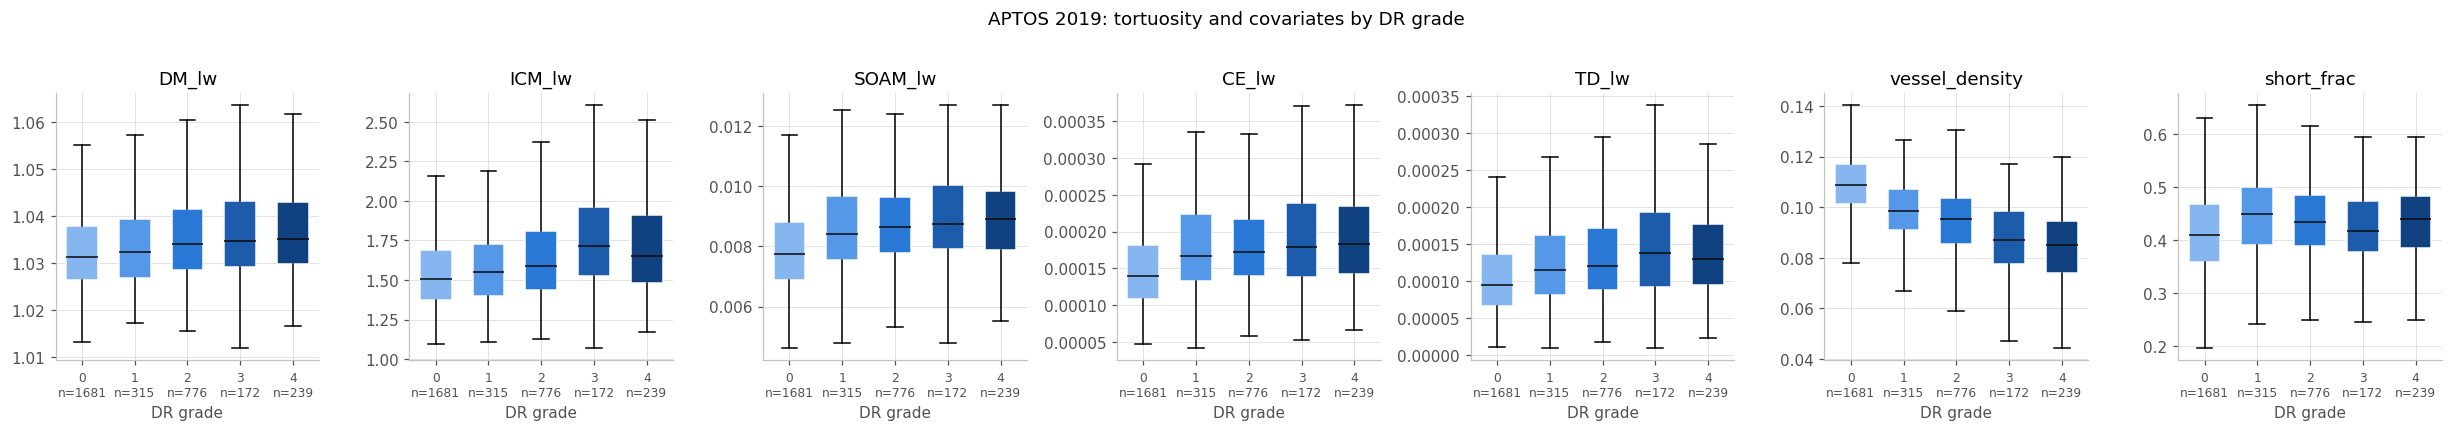

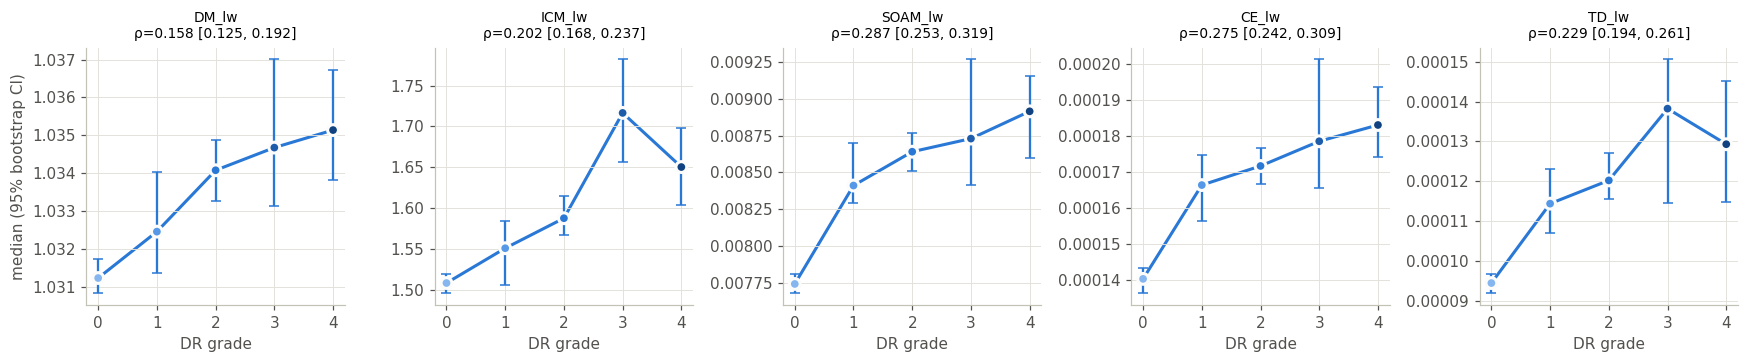

In [21]:
# 그림 1: 등급별 분포 (상자그림)
def plot_box_by_grade(df, metrics, title, fname):
    grades = sorted(df.grade.unique())
    fig, axes = plt.subplots(1, len(metrics), figsize=(3.2 * len(metrics), 3.8))
    for ax, m in zip(np.atleast_1d(axes), metrics):
        data = [df.loc[df.grade == g, m].dropna().values for g in grades]
        bp = ax.boxplot(data, patch_artist=True, showfliers=False, widths=0.6, medianprops=dict(color='#0b0b0b'))
        for patch, g in zip(bp['boxes'], grades):
            patch.set_facecolor(GRADE_COLORS[g]); patch.set_edgecolor('#fcfcfb')
        ax.set_xticks(range(1, len(grades) + 1))
        ax.set_xticklabels([f'{g}\nn={len(x)}' for g, x in zip(grades, data)], fontsize=8)
        ax.set_title(m); ax.set_xlabel('DR grade')
    plt.suptitle(title, y=1.02)
    plt.tight_layout(); savefig(fname); plt.show()


plot_box_by_grade(aptos_q, LW + ['vessel_density', 'short_frac'],
                  'APTOS 2019: tortuosity and covariates by DR grade', '01_box_by_grade')

# 그림 2: 등급별 중앙값과 부트스트랩 95% CI (추세)
def median_ci(v, n_boot=1000):
    v = np.asarray(v)
    if len(v) == 0:
        return np.nan, np.nan, np.nan
    b = np.median(v[RNG.integers(0, len(v), size=(n_boot, len(v)))], axis=1)
    return np.median(v), *np.percentile(b, [2.5, 97.5])


grades = sorted(aptos_q.grade.unique())
fig, axes = plt.subplots(1, len(LW), figsize=(3.2 * len(LW), 3.4))
for ax, m in zip(axes, LW):
    stats_g = [median_ci(aptos_q.loc[aptos_q.grade == g, m].dropna().values) for g in grades]
    med = np.array([s[0] for s in stats_g]); lo = np.array([s[1] for s in stats_g]); hi = np.array([s[2] for s in stats_g])
    ax.plot(grades, med, color='#2a78d6', lw=2, zorder=1)
    ax.errorbar(grades, med, yerr=[med - lo, hi - med], fmt='none', ecolor='#2a78d6', elinewidth=1.5, capsize=3)
    ax.scatter(grades, med, s=50, color=[GRADE_COLORS[g] for g in grades], edgecolor='#fcfcfb', linewidth=2, zorder=3)
    r = corr.loc[m]
    ax.set_title(f"{m}\nρ={r['Spearman ρ']:.3f} [{r['ρ_lo']:.3f}, {r['ρ_hi']:.3f}]", fontsize=9)
    ax.set_xticks(grades); ax.set_xlabel('DR grade')
axes[0].set_ylabel('median (95% bootstrap CI)')
plt.tight_layout(); savefig('aptos_02_median_trend'); plt.show()

In [22]:
# 등급별 비교: 각 등급 vs 0등급 (Mann-Whitney, Cliff's δ = 효과 크기)
def cliffs_delta(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.nan
    U = stats.mannwhitneyu(a, b).statistic
    return 2 * U / (len(a) * len(b)) - 1


rows = []
base = {m: aptos_q.loc[aptos_q.grade == 0, m].dropna().values for m in LW}
for m in LW:
    for g in grades:
        if g == 0:
            continue
        a = aptos_q.loc[aptos_q.grade == g, m].dropna().values
        rows.append({'지표': m, '비교': f'{GRADE_NAMES[g]} vs 0', "Cliff's δ": cliffs_delta(a, base[m]),
                     'p': stats.mannwhitneyu(a, base[m]).pvalue if len(a) else np.nan})
pair = pd.DataFrame(rows)
pair['p (Holm)'] = holm(pair['p'])
pair.to_csv(CFG.WORK / 'aptos_pairwise_vs_grade0.csv', index=False)
print("Cliff's δ: 0.15 미만 무시할 만함, 0.15~0.33 작음, 0.33~0.47 중간, 0.47 이상 큼 (양수 = 해당 등급이 더 높음)")
display(pair.pivot(index='비교', columns='지표', values="Cliff's δ").round(3))
display(pair.pivot(index='비교', columns='지표', values='p (Holm)').map(lambda v: f'{v:.2g}'))

# 의뢰 필요 DR(2등급 이상) 판별 AUC
y = (aptos_q.grade >= CFG.REFERABLE).astype(int).values
rows = []
for m in LW + ['vessel_density', 'short_frac']:
    v = aptos_q[m].values
    ok = ~np.isnan(v)
    auc = roc_auc_score(y[ok], v[ok])
    idx = RNG.integers(0, ok.sum(), size=(1000, ok.sum()))
    boots = [roc_auc_score(y[ok][i], v[ok][i]) for i in idx if 0 < y[ok][i].sum() < len(i)]
    lo, hi = np.percentile(boots, [2.5, 97.5])
    rows.append({'변수': m, 'AUC': auc, '95% CI': f'{lo:.3f} ~ {hi:.3f}',
                 '방향': '높을수록 DR' if auc >= 0.5 else '낮을수록 DR'})
auc_tab = pd.DataFrame(rows).set_index('변수')
auc_tab.to_csv(CFG.WORK / 'aptos_referable_auc.csv')
print(f'\n의뢰 필요 DR(등급 ≥ {CFG.REFERABLE}) 판별 AUC: 0.5 = 무작위, 0.5에서 멀수록 판별력이 큼')
display(auc_tab.round(3))

Cliff's δ: 0.15 미만 무시할 만함, 0.15~0.33 작음, 0.33~0.47 중간, 0.47 이상 큼 (양수 = 해당 등급이 더 높음)


지표,CE_lw,DM_lw,ICM_lw,SOAM_lw,TD_lw
비교,,,,,
1 Mild vs 0,0.260,0.061,0.086,0.263,0.178
2 Moderate vs 0,0.317,0.178,0.191,0.322,0.250
3 Severe vs 0,0.358,0.225,0.373,0.395,0.339
4 PDR vs 0,0.370,0.229,0.298,0.391,0.316


지표,CE_lw,DM_lw,ICM_lw,SOAM_lw,TD_lw
비교,,,,,
1 Mild vs 0,1.6e-12,0.084,0.031,1.1e-12,2e-06
2 Moderate vs 0,2.2e-35,7.5e-12,2.5e-13,2.1e-36,4.3e-22
3 Severe vs 0,1.1e-13,3.4e-06,1e-14,2e-16,1.6e-12
4 PDR vs 0,3.3e-19,4.9e-08,7.9e-13,2.1e-21,2.9e-14



의뢰 필요 DR(등급 ≥ 2) 판별 AUC: 0.5 = 무작위, 0.5에서 멀수록 판별력이 큼


,AUC,95% CI,방향
변수,,,
DM_lw,0.593,0.573 ~ 0.612,높을수록 DR
ICM_lw,0.613,0.592 ~ 0.634,높을수록 DR
SOAM_lw,0.652,0.632 ~ 0.670,높을수록 DR
CE_lw,0.646,0.625 ~ 0.666,높을수록 DR
TD_lw,0.624,0.604 ~ 0.645,높을수록 DR
vessel_density,0.213,0.197 ~ 0.230,낮을수록 DR
short_frac,0.553,0.534 ~ 0.573,높을수록 DR


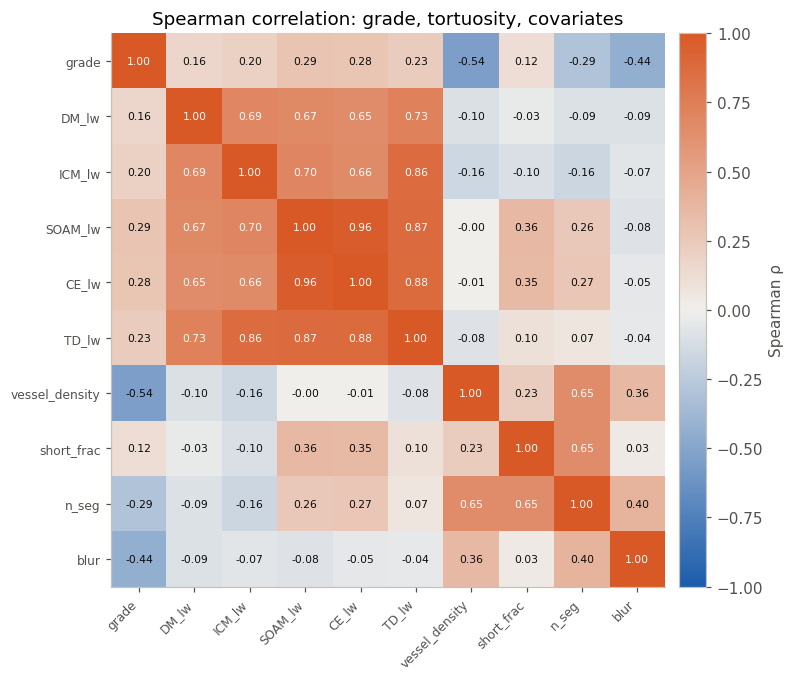

굴곡도가 혈관 밀도·짧은 조각 비율과 강하게 얽혀 있다면, 등급과의 상관 일부가 분할 결과의 양이나 파편화에서 왔을 수 있습니다.


In [23]:
# 지표·공변량·등급 사이의 Spearman 상관 행렬
cols = ['grade'] + LW + ['vessel_density', 'short_frac', 'n_seg', 'blur']
cm = aptos_q[cols].corr(method='spearman')
fig, ax = plt.subplots(figsize=(7.5, 6.3))
im = ax.imshow(cm.values, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=8)
ax.grid(False)
for i in range(len(cols)):
    for j in range(len(cols)):
        v = cm.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                color='#fcfcfb' if abs(v) > 0.6 else '#0b0b0b')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02).set_label('Spearman ρ')
ax.set_title('Spearman correlation: grade, tortuosity, covariates')
plt.tight_layout(); savefig('aptos_03_correlation_matrix'); plt.show()
print('굴곡도가 혈관 밀도·짧은 조각 비율과 강하게 얽혀 있다면, 등급과의 상관 일부가 분할 결과의 양이나 파편화에서 왔을 수 있습니다.')

## 9. 민감도 분석과 병변 인공물 점검

같은 결론이 분석 조건을 바꿔도 유지되는지 확인합니다.

| 조건 | 의도 |
|---|---|
| 품질 필터 없음 / 선명한 영상 절반만 | 영상 품질에 따라 결과가 흔들리는지 |
| 긴 세그먼트(≥80px), 굵은 혈관(폭≥4px), 둘 다 | 병변 오분할로 생기는 짧고 가는 조각을 빼도 유지되는지 |
| 4등급(증식성) 제외 | 신생혈관이 많은 최중증 영상이 결과를 끌고 가는지 |

마지막 그림(forest plot)에서 모든 조건의 ρ가 같은 쪽에 있고 CI가 0을 넘지 않으면 결과가 견고하다고 볼 수 있습니다.

민감도 분석:   0%|          | 0/7 [00:00<?, ?it/s]

Spearman ρ


지표,CE_lw,DM_lw,ICM_lw,SOAM_lw,TD_lw
분석,,,,,
기본 (품질 필터),0.275,0.158,0.202,0.287,0.229
품질 필터 없음,0.250,0.157,0.206,0.262,0.220
선명한 영상 절반,0.250,0.122,0.149,0.261,0.184
긴 세그먼트 (≥80px),0.241,0.134,0.206,0.261,0.217
굵은 혈관 (폭≥4px),0.205,0.099,0.132,0.238,0.141
길고 굵은 혈관,0.173,0.079,0.136,0.211,0.141
4등급 제외,0.264,0.145,0.183,0.274,0.216


부분 ρ (혈관 밀도·흐림·짧은 조각 비율 보정)


지표,CE_lw,DM_lw,ICM_lw,SOAM_lw,TD_lw
분석,,,,,
기본 (품질 필터),0.245,0.122,0.171,0.253,0.204
품질 필터 없음,0.241,0.122,0.166,0.250,0.204
선명한 영상 절반,0.237,0.135,0.166,0.250,0.191
긴 세그먼트 (≥80px),0.217,0.097,0.165,0.231,0.190
굵은 혈관 (폭≥4px),0.180,0.078,0.116,0.211,0.132
길고 굵은 혈관,0.164,0.064,0.116,0.194,0.130
4등급 제외,0.235,0.114,0.163,0.243,0.197


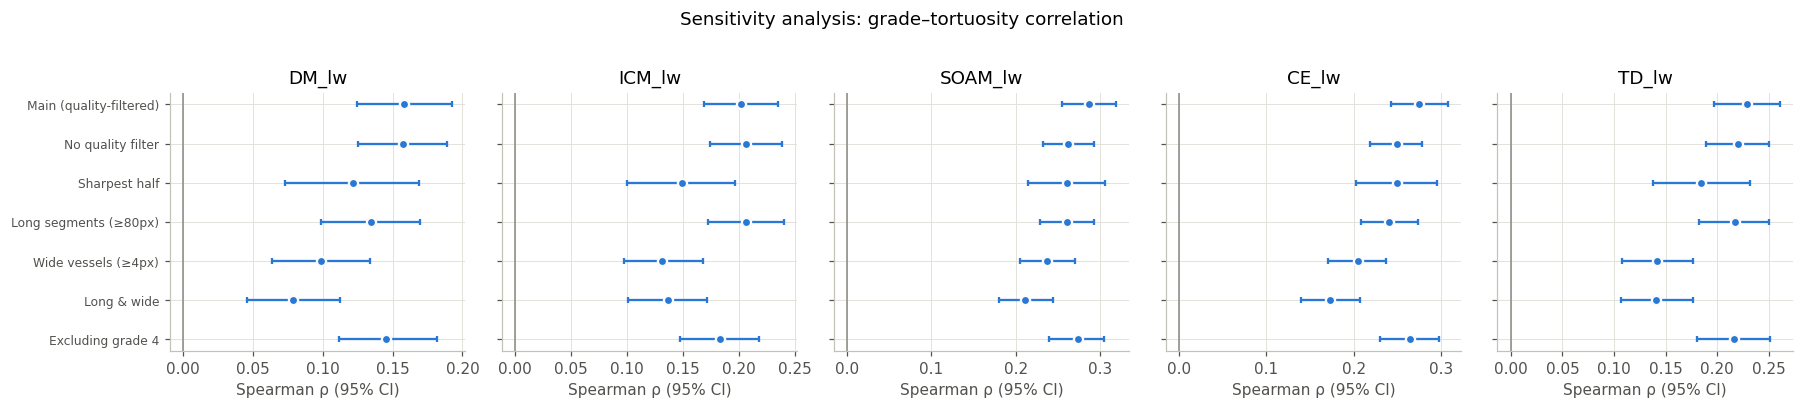

In [24]:
def reaggregate(seg_df, base_img, **kw):
    agg = seg_df.groupby('image_id').apply(lambda s: pd.Series(aggregate_segments(s, **kw)))
    keep = [c for c in base_img.columns if c not in agg.columns]
    return base_img[keep].merge(agg, left_on='image_id', right_index=True, how='left')


variants = {
    '기본 (품질 필터)': aptos_q,
    '품질 필터 없음': aptos_img,
    '선명한 영상 절반': aptos_q[aptos_q.blur >= aptos_q.blur.median()],
    '긴 세그먼트 (≥80px)': reaggregate(aptos_seg, aptos_q, min_len=80),
    '굵은 혈관 (폭≥4px)': reaggregate(aptos_seg, aptos_q, min_width=4),
    '길고 굵은 혈관': reaggregate(aptos_seg, aptos_q, min_len=80, min_width=4),
    '4등급 제외': aptos_q[aptos_q.grade < 4],
}
sens_rows = []
for vname, d in tqdm(variants.items(), desc='민감도 분석'):
    r = correlation_table(d, LW, ordinal=False)
    for m in LW:
        sens_rows.append({'분석': vname, '지표': m, 'n': r.loc[m, 'n'], 'ρ': r.loc[m, 'Spearman ρ'],
                          'ρ_lo': r.loc[m, 'ρ_lo'], 'ρ_hi': r.loc[m, 'ρ_hi'],
                          '부분 ρ': r.loc[m, '부분 ρ'], 'p (JT, Holm)': r.loc[m, 'p (JT, Holm)']})
sens = pd.DataFrame(sens_rows)
sens.to_csv(CFG.WORK / 'aptos_sensitivity.csv', index=False)
order = list(variants)
print('Spearman ρ')
display(sens.pivot(index='분석', columns='지표', values='ρ').reindex(order).round(3))
print('부분 ρ (혈관 밀도·흐림·짧은 조각 비율 보정)')
display(sens.pivot(index='분석', columns='지표', values='부분 ρ').reindex(order).round(3))

fig, axes = plt.subplots(1, len(LW), figsize=(3.3 * len(LW), 3.6), sharey=True)
ypos = np.arange(len(order))[::-1]
for ax, m in zip(axes, LW):
    s = sens[sens.지표 == m].set_index('분석').reindex(order)
    ax.axvline(0, color='#898781', lw=1)
    ax.errorbar(s['ρ'], ypos, xerr=[s['ρ'] - s['ρ_lo'], s['ρ_hi'] - s['ρ']], fmt='o', color='#2a78d6',
                ecolor='#2a78d6', ms=6, capsize=2, mec='#fcfcfb', mew=1.5)
    ax.set_title(m); ax.set_xlabel('Spearman ρ (95% CI)')
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(['Main (quality-filtered)', 'No quality filter', 'Sharpest half', 'Long segments (≥80px)',
                         'Wide vessels (≥4px)', 'Long & wide', 'Excluding grade 4'], fontsize=8)
plt.suptitle('Sensitivity analysis: grade–tortuosity correlation', y=1.02)
plt.tight_layout(); savefig('aptos_04_sensitivity_forest'); plt.show()

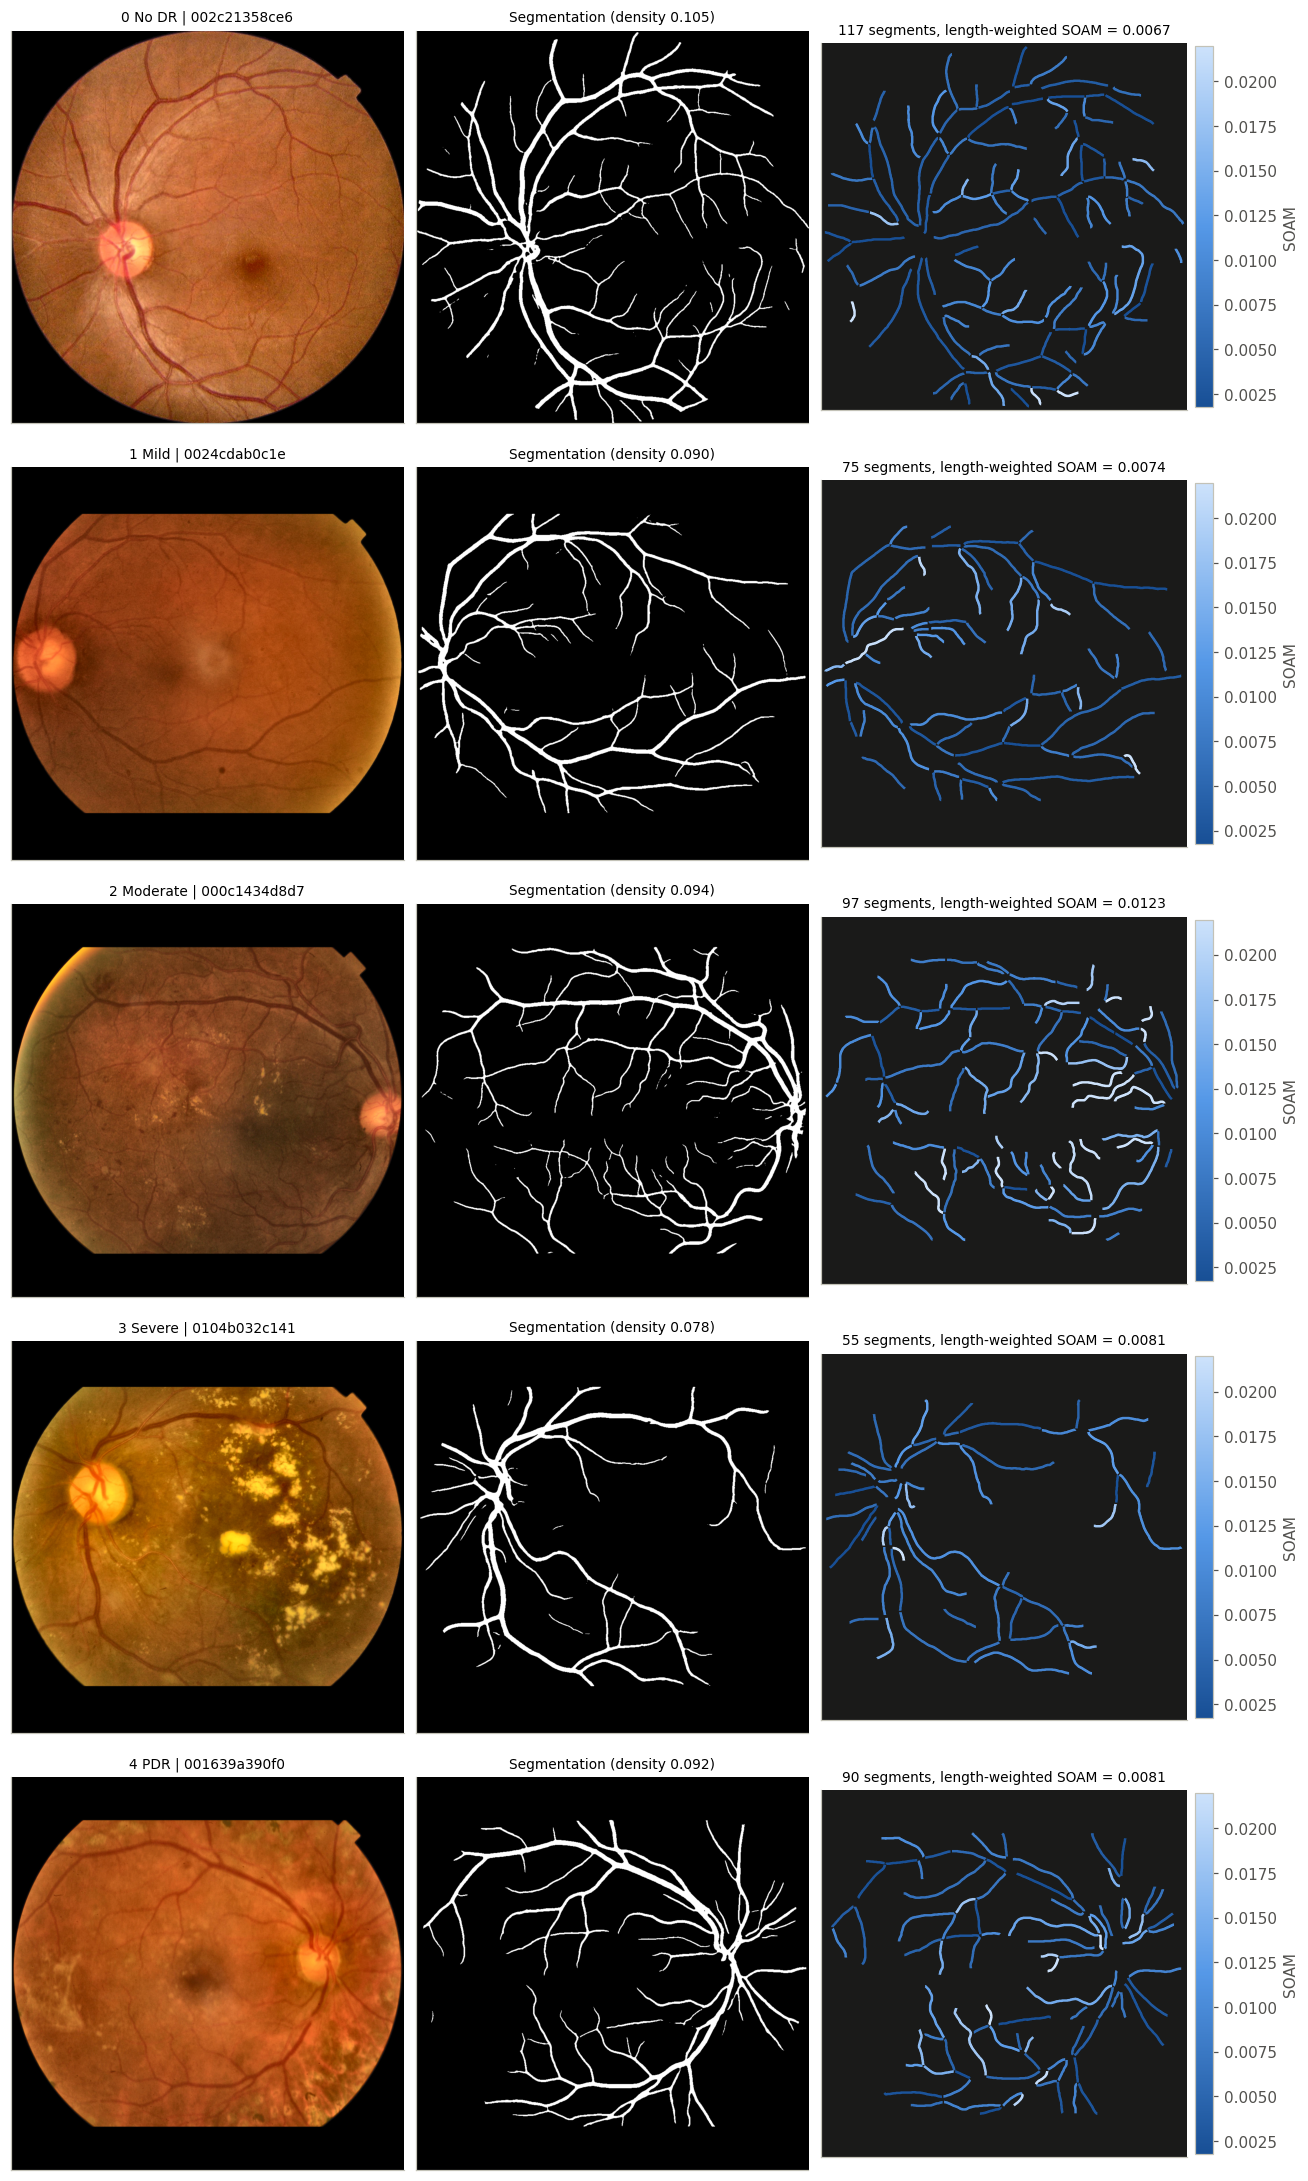

In [25]:
# 등급별 예시: 원본 | 분할 | 세그먼트별 굴곡도 지도 (모든 등급 같은 색 범위)
def plot_tortuosity_map(img, ves, fov, axes, metric='SOAM', title='', clim=None):
    seg, info, lines = image_tortuosity(ves, fov, return_lines=True)
    axes[0].imshow(img); axes[0].set_title(title, fontsize=9)
    axes[1].imshow(ves, cmap='gray'); axes[1].set_title(f"Segmentation (density {info['vessel_density']:.3f})", fontsize=9)
    ax = axes[2]
    ax.set_facecolor('#1a1a19')
    if len(seg):
        v = seg[metric].values
        lc = LineCollection([l[:, ::-1] for l in lines], cmap=TORT_CMAP, linewidths=1.6)
        lc.set_array(v)
        lc.set_clim(*(clim or (np.percentile(v, 5), np.percentile(v, 95))))
        ax.add_collection(lc)
        plt.colorbar(lc, ax=ax, fraction=0.046, pad=0.02).set_label(metric)
    ax.set_xlim(0, ves.shape[1]); ax.set_ylim(ves.shape[0], 0); ax.set_aspect('equal')
    ax.set_title(f'{len(seg)} segments, length-weighted {metric} = {aggregate_segments(seg)[f"{metric}_lw"]:.4f}', fontsize=9)
    for a in axes:
        a.set_xticks([]); a.set_yticks([]); a.grid(False)


MAP_METRIC = max(LW, key=lambda m: ICC.get(m, -1)).replace('_lw', '') if ICC else 'SOAM'   # 일치도가 가장 높은 지표
if aptos_qc:
    gs = sorted(aptos_qc)
    clim = tuple(np.percentile(aptos_seg[MAP_METRIC], [5, 95])) if len(aptos_seg) else None
    fig, axes = plt.subplots(len(gs), 3, figsize=(12, 4 * len(gs)))
    axes = np.atleast_2d(axes)
    for i, g in enumerate(gs):
        iid, im, b, f = aptos_qc[g][0]
        plot_tortuosity_map(im, b, f, axes[i], metric=MAP_METRIC, title=f'{GRADE_NAMES[g]} | {iid}', clim=clim)
    plt.tight_layout(); savefig('aptos_05_tortuosity_maps'); plt.show()
else:
    print('이번 실행에서 새로 처리한 영상이 없어 예시 지도가 없습니다 (저장된 결과를 불러옴).')

## 10. 결과 요약

지표마다 핵심 결과를 한 줄로 정리합니다. **결론 판정**은 아래 네 조건을 몇 개 만족하는지 세는 방식입니다.
1. Spearman ρ의 95% CI가 0을 포함하지 않음
2. 순서형 경향(JT) Holm 보정 p < 0.05
3. 혈관 밀도·흐림·짧은 조각 비율을 보정한 부분 ρ가 같은 방향이고 Holm 보정 p < 0.05
4. 민감도 분석 7개 조건 모두에서 ρ의 방향이 같음

여기에 FIVES ICC(측정 신뢰도)를 함께 봐야 합니다. 신뢰도가 낮은 지표에서 4개를 모두 만족해도 분할 오차가 섞였을 수 있습니다.

In [26]:
rows = []
for m in LW:
    r = corr.loc[m]
    s = sens[sens.지표 == m]
    sign = np.sign(r['Spearman ρ'])
    c1 = (r['ρ_lo'] > 0) or (r['ρ_hi'] < 0)
    c2 = r['p (JT, Holm)'] < 0.05
    c3 = (np.sign(r['부분 ρ']) == sign) and (r['p (부분 ρ, Holm)'] < 0.05)
    c4 = bool((np.sign(s['ρ']) == sign).all())
    score = int(c1) + int(c2) + int(c3) + int(c4)
    direction = '높을수록 등급↑' if sign > 0 else '낮을수록 등급↑'
    verdict = ('일관된 연관' if score == 4 else '부분적 연관' if score >= 2 else '연관 근거 부족')
    rows.append({'지표': m, 'FIVES ICC': ICC.get(m, np.nan), '측정 신뢰도': icc_label(ICC.get(m)),
                 'ρ [95% CI]': f"{r['Spearman ρ']:.3f} [{r['ρ_lo']:.3f}, {r['ρ_hi']:.3f}]",
                 '부분 ρ': round(r['부분 ρ'], 3), 'OR/SD': round(r.get('OR/SD', np.nan), 3),
                 '방향': direction, '충족 조건 (4개 중)': score, '판정': verdict})
summary = pd.DataFrame(rows).set_index('지표')
summary.to_csv(CFG.WORK / 'aptos_summary.csv')
display(summary)

print('\n[한 줄 요약]')
for m, r in summary.iterrows():
    print(f"- {m}: {r['판정']} ({r['방향']}, ρ {r['ρ [95% CI]']}, 조건 {r['충족 조건 (4개 중)']}/4, 측정 신뢰도 {r['측정 신뢰도']})")
print('\n※ 나이·고혈압·당뇨 유병기간을 보정하지 못했고 APTOS에는 환자 ID가 없어 양안 중복을 제거할 수 없습니다. '
      '결과는 인과가 아닌 연관성으로 해석하세요.')

print('\n출력 파일')
for p in sorted(CFG.WORK.rglob('*')):
    if p.is_file():
        print(f'  {p.relative_to(CFG.WORK)}  ({p.stat().st_size / 1e6:.1f} MB)')

,FIVES ICC,측정 신뢰도,ρ [95% CI],부분 ρ,OR/SD,방향,충족 조건 (4개 중),판정
지표,,,,,,,,
DM_lw,0.330380,낮음,"0.158 [0.125, 0.192]",0.122,1.033,높을수록 등급↑,4,일관된 연관
ICM_lw,0.425903,낮음,"0.202 [0.168, 0.237]",0.171,1.227,높을수록 등급↑,4,일관된 연관
SOAM_lw,0.830499,좋음,"0.287 [0.253, 0.319]",0.253,1.831,높을수록 등급↑,4,일관된 연관
CE_lw,0.652826,보통,"0.275 [0.242, 0.309]",0.245,1.650,높을수록 등급↑,4,일관된 연관
TD_lw,0.670703,보통,"0.229 [0.194, 0.261]",0.204,1.419,높을수록 등급↑,4,일관된 연관



[한 줄 요약]
- DM_lw: 일관된 연관 (높을수록 등급↑, ρ 0.158 [0.125, 0.192], 조건 4/4, 측정 신뢰도 낮음)
- ICM_lw: 일관된 연관 (높을수록 등급↑, ρ 0.202 [0.168, 0.237], 조건 4/4, 측정 신뢰도 낮음)
- SOAM_lw: 일관된 연관 (높을수록 등급↑, ρ 0.287 [0.253, 0.319], 조건 4/4, 측정 신뢰도 좋음)
- CE_lw: 일관된 연관 (높을수록 등급↑, ρ 0.275 [0.242, 0.309], 조건 4/4, 측정 신뢰도 보통)
- TD_lw: 일관된 연관 (높을수록 등급↑, ρ 0.229 [0.194, 0.261], 조건 4/4, 측정 신뢰도 보통)

※ 나이·고혈압·당뇨 유병기간을 보정하지 못했고 APTOS에는 환자 ID가 없어 양안 중복을 제거할 수 없습니다. 결과는 인과가 아닌 연관성으로 해석하세요.

출력 파일
  .virtual_documents/__notebook_source__.ipynb  (0.1 MB)
  aptos_analysis_table.csv  (1.6 MB)
  aptos_correlation_results.csv  (0.0 MB)
  aptos_image_tortuosity.csv  (1.7 MB)
  aptos_pairwise_vs_grade0.csv  (0.0 MB)
  aptos_referable_auc.csv  (0.0 MB)
  aptos_segments.csv.gz  (29.0 MB)
  aptos_sensitivity.csv  (0.0 MB)
  aptos_summary.csv  (0.0 MB)
  figures/01_box_by_grade.png  (0.1 MB)
  figures/01_fives_examples.png  (1.4 MB)
  figures/02_training.png  (0.1 MB)
  figures/03_fives_test_examples.png  (1.9 MB)
  figures/05_bland_altman